# Part 01 — Charter, Literature, EDA & Features

Satellite notebook split from `capstone_with_results.ipynb` to keep the master lighter to open.
Outputs/source sync automatically via `scripts/sync_notebook_parts.py` (run the final sync cell).


In [ ]:
# ── PART BOOTSTRAP: Part 01 — Charter, Literature, EDA & Features ──
# Lightweight satellite notebook — syncs back into notebooks/capstone_with_results.ipynb
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "src" / "vision_brain.py").is_file() and (base / "explanations" / "build_all.py").is_file():
            return base
        if (base / "src" / "vision_brain.py").is_file():
            return base
    return Path.cwd().parent if Path.cwd().name in {"notebooks", "parts"} else Path.cwd()

REPO_ROOT = _find_root()
SRC = REPO_ROOT / "src"
DATA = REPO_ROOT / "Data"
if not DATA.is_dir():
    DATA = REPO_ROOT / "data"
sys.path.insert(0, str(SRC))
sys.path.insert(0, str(REPO_ROOT / "scripts")) if (REPO_ROOT / "scripts").is_dir() else None

try:
    import torch
    TORCH_OK = True
except Exception:
    TORCH_OK = False

# Optional shared helpers used by several sections
try:
    from cm_helpers import plot_confusion_matrices_pair  # noqa: F401
except Exception:
    plot_confusion_matrices_pair = None

import numpy as np  # noqa: F401
import pandas as pd  # noqa: F401
import matplotlib.pyplot as plt  # noqa: F401

print(f"Part notebook ready | root={REPO_ROOT} | TORCH_OK={TORCH_OK} | DATA={DATA}")
print("When finished: run the last cell to sync outputs → capstone_with_results.ipynb")

---

## Environment Setup Cell
> **Run this cell FIRST** on any platform — local, Google Colab, or Kaggle.
> It auto-detects the environment, mounts storage, installs packages, and sets the `DATA` path.
> All other cells work unchanged after this runs.


In [1]:
import os, sys
from pathlib import Path

# ── 1. Detect environment ─────────────────────────────────────────────────────
IN_COLAB  = "google.colab" in sys.modules or os.path.exists("/content")
IN_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
IN_LOCAL  = not IN_COLAB and not IN_KAGGLE

env_name = "Google Colab" if IN_COLAB else ("Kaggle" if IN_KAGGLE else "Local Machine")
print(f"Environment detected : {env_name}")

# ── 2. GPU check ──────────────────────────────────────────────────────────────
try:
    import torch
    gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None (CPU only)"
    print(f"GPU available        : {gpu}")
except Exception:
    print("GPU check            : torch not yet installed")

# ── 3. Install missing packages ───────────────────────────────────────────────
pkgs_needed = []
try:
    import lightgbm
except ImportError:
    pkgs_needed.append("lightgbm")
try:
    import imblearn
except ImportError:
    pkgs_needed.append("imbalanced-learn")
for _pkg in ["datasets", "torchvision", "shap"]:
    try:
        __import__(_pkg)
    except ImportError:
        pkgs_needed.append(_pkg)
_torch_index = "https://download.pytorch.org/whl/cu121" if (IN_COLAB or IN_KAGGLE) else "https://download.pytorch.org/whl/cpu"
try:
    import torch
    from packaging import version as _pkg_version
    if _pkg_version.parse(torch.__version__.split("+")[0]) < _pkg_version.parse("2.4.0"):
        pkgs_needed.append(f"torch>=2.4 torchvision --index-url {_torch_index}")
    else:
        _ = torch.zeros(1)
except Exception:
    pkgs_needed.append(f"torch>=2.4 torchvision --index-url {_torch_index}")

if pkgs_needed:
    print(f"Installing           : {pkgs_needed}")
    for pkg in pkgs_needed:
        os.system(f"pip install -q {pkg}")
    print("Packages installed. If torch was installed, restart the kernel once.")
else:
    print("Packages             : all present")

def _repo_root(start: Path) -> Path:
    """Project root (contains src/, notebooks/, Data/)."""
    start = start.resolve()
    if (start / "src").is_dir() and (start / "notebooks").is_dir():
        return start
    if (start.parent / "src").is_dir():
        return start.parent
    return start.parent


def _resolve_data_dir(start: Path) -> Path:
    """Pick data/ that contains CSVs or vision_cache."""
    root = _repo_root(start)
    candidates = []
    for base in [root, start, start.parent]:
        for name in ("data", "Data"):
            d = base / name
            if d.is_dir():
                candidates.append(d)
    for d in candidates:
        if any(d.glob("*.csv")) or (d / "vision_cache").is_dir():
            return d
    return root / "data"

# ── 4. Mount storage & set DATA path ─────────────────────────────────────────
_nb_dir = Path.cwd() # For colab, this is /content
# REPO_ROOT is initialized here, but may be overridden below in Colab specific logic.
REPO_ROOT = _repo_root(_nb_dir)

if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive/capstone"):
        print("Mounting Google Drive...")
        drive.mount("/content/drive")
    # ------------------------------------------------------------------ #
    # EDIT THIS PATH to match where your Data/ folder is in Google Drive  #
    DRIVE_DATA = Path("/content/drive/MyDrive/capstone/Smart-Shield-AI/Data")
    # Explicitly set REPO_ROOT to the parent of DRIVE_DATA path for Colab
    REPO_ROOT = DRIVE_DATA.parent
    print("REPO_ROOT:    ",REPO_ROOT)
    # ------------------------------------------------------------------ #
    if DRIVE_DATA.exists():
        DATA = DRIVE_DATA
        # REPO_ROOT is already correctly set above to DRIVE_DATA.parent
    else:
        # Fallback: look for uploaded Data/ in /content
        DATA = Path("/content/Data") if Path("/content/Data").exists() else DRIVE_DATA
        if not DATA.exists():
            print(f"WARNING: Data folder not found at {DATA}")
            print("  Upload your Data/ folder to Colab or update DRIVE_DATA path above.")


elif IN_KAGGLE:
    # Kaggle: add your dataset as input, it appears at /kaggle/input/<dataset-name>/
    _kag_candidates = list(Path("/kaggle/input").glob("*/Data"))
    DATA = _kag_candidates[0] if _kag_candidates else Path("/kaggle/input")
    print(f"Kaggle input path    : {DATA}")

else:  # Local
    try:
        from IPython import get_ipython
        _ip = get_ipython()
        if _ip and "__vsc_ipynb_file__" in _ip.user_ns:
            _nb_dir = Path(_ip.user_ns["__vsc_ipynb_file__"]).parent
    except Exception:
        pass
    DATA = _resolve_data_dir(_nb_dir)

# Add project src to sys.path for all environments
if (REPO_ROOT / "src").is_dir() and str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

DATA_DIR = str(DATA)
MODEL_DIR = REPO_ROOT / "models"

# ── 5. Summary ────────────────────────────────────────────────────────────────
print(f"DATA path            : {DATA}")
print(f"Data folder exists   : {DATA.is_dir()}")
if DATA.is_dir():
    csvs = [f.name for f in DATA.glob("*.csv")][:6]
    print(f"CSVs found           : {csvs}")

# Re-import torch after potential install so rest of notebook picks it up
try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    _ver  = torch.__version__
    _t    = torch.zeros(2)
    _lin  = nn.Linear(2,2)
    _opt  = optim.Adam(_lin.parameters(), lr=1e-3, weight_decay=1e-4)
    del _t, _lin, _opt
    TORCH_OK = True
    device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch              : {_ver}  |  device={device}")
except Exception as _e:
    TORCH_OK = False
    torch = nn = optim = DataLoader = TensorDataset = None
    device = None
    print(f"PyTorch              : unavailable ({type(_e).__name__}: {str(_e)[:80]})")

print("\nSetup complete. You can now run all remaining cells.")



Environment detected : Google Colab
GPU available        : None (CPU only)
Packages             : all present
Mounting Google Drive...
Mounted at /content/drive
REPO_ROOT:     /content/drive/MyDrive/capstone/Smart-Shield-AI
DATA path            : /content/drive/MyDrive/capstone/Smart-Shield-AI/Data
Data folder exists   : True
CSVs found           : ['dft-road-casualty-statistics-collision-last-5-years.csv', 'SDOT_Collisions_All_Years.csv', 'TorontoCollisionData.csv']
PyTorch              : 2.11.0+cpu  |  device=cpu

Setup complete. You can now run all remaining cells.


This document is the **Master Project Specification** for Group 6. It is designed to be shared with your team members and presented to your professor. It combines the business case, the technical "3-Brain" architecture, the specific mathematical logic for the Safety Score, and a 100% reliable data acquisition plan.

---

# **Project Charter: The Ontario “Smart-Shield”**
### **Multimodal AI for Dynamic Highway Risk & Speed Optimization**

**Course:** PROG50141 – Python for Machine Learning  
**Project Lead:** Afolabi Adesina | **Group:** 6  
**Timeline:** 8 Weeks
**Target Region:** 400-Series Highway Corridors, Ontario, Canada

---

## **1. Executive Summary**
The **Ontario Smart-Shield** is a multimodal AI system designed to solve the "Static Data Gap" in current navigation tools. While Google Maps tracks traffic flow, it fails to identify *causal* hazards like black ice or sudden whiteouts. Our system "listens" to official alerts (NLP), "sees" road conditions (Computer Vision), and "decides" on safe speed limits (Logistic Optimization).

---

## **2. Technical Architecture (The 3-Brain System)**

### **Pillar 1: The NLP Brain (The Social Listener)**
*   **Logic:** Standard sensors cannot detect qualitative events (e.g., "stalled vehicle" or "police activity"). This module turns unstructured government text into a numeric risk index.
*   **Pipeline:** Cleaning $\rightarrow$ Tokenization $\rightarrow$ Porter Stemming.
*   **The Formula (TF-IDF):**
    $$T = \sum_{i=1}^{n} (tf_{i,d} \cdot \log \frac{N}{df_i})$$
*   **Term Meaning:** $tf$ (frequency of "Danger" words in an alert) is weighted against $idf$ (how rare/significant that word is across all alerts).

### **Pillar 2: The Vision Brain (The Visual Sensor)**
*   **Logic:** Uses live Highway 401 CCTV feeds to detect road surface texture that thermometers might miss (e.g., slush vs. clear asphalt).
*   **Pipeline:** OpenCV normalization (224x224 resize, pixel scaling 0-1) $\rightarrow$ Convolutional Neural Network (CNN).
*   **The Formula (Softmax Probability):**
    $$V = \frac{e^{z_{hazard}}}{\sum_{j=1}^K e^{z_j}}$$
*   **Term Meaning:** $V$ is the confidence score (0.0 to 1.0) that the current road image contains a hazard (Ice/Snow).

### **Pillar 3: The Logistic Optimizer (The Decision Engine)**
*   **Logic:** Fuses all inputs to classify the road segment as "Safe" vs "High Risk."
*   **Method:** Logistic Regression optimized via **GridSearchCV** and **Lasso (L1) Regularization**.
*   **The Model Equation:**
    $$P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 T + \beta_2 V + \beta_3 E)}}$$
*   **Term Meaning:** $\beta_n$ are the weights. **Lasso** identifies which brain (NLP or Vision) is most reliable in the current weather and zeros out redundant sensors.

---

## **3. The Proprietary Safety Score Framework ($S$)**

To provide actionable advice to the driver, we generate a **Composite Safety Score**.

### **The Master Equation:**
$$S = \left( (w_T \cdot T) + (w_V \cdot V) + (w_E \cdot E_{index}) \right) \times 100$$

| Term | Meaning | Optimization Logic |
| :--- | :--- | :--- |
| **$w$ (Weights)** | Importance of each brain | Adjusted via **Lasso**. At night, $w_V$ (Vision) drops; $w_T$ (Text) rises. |
| **$E_{index}$** | Environmental Risk | A Min-Max scaled index of Temperature, Wind, and Visibility. |
| **$S$** | Final Score | A value from **0 (Safe)** to **100 (Extreme Hazard)**. |

### **The Dynamic Decision Table:**
| Safety Score ($S$) | Risk Category | Recommended Speed ($V_{rec}$) |
| :--- | :--- | :--- |
| **0 – 30** | Low Risk (Green) | 100% of Posted Limit (100-110 km/h) |
| **31 – 70** | Moderate (Yellow) | 80% of Posted Limit (e.g., 80 km/h) |
| **71 – 100** | High Risk (Red) | 60% of Posted Limit (e.g., 60 km/h) |

---

## **4. Data Acquisition & Work Breakdown (WBS)**

### **Data Samples (Python View):**
*   **Structured:** `[Temp: -12C, Wind: 40km/h, Visibility: 0.5km]`
*   **NLP Text:** `"Hwy 401 @ Milton: Black ice reported. Multi-vehicle collision."`
*   **Vision Matrix:** `array([[45, 210, 215], ...])` (High values = white snow/ice).

### **8-Week Roadmap:**
1.  **Weeks 1-2 (Foundations):** Afolabi to ingest Ontario Collision CSVs and build the Linear Baseline.
2.  **Week 3 (NLP):** Team Member 2 to build the TF-IDF scraper for Ontario 511 text logs.
3.  **Week 4 (Vision):** Team Member 3 to implement OpenCV normalization for live 401 camera URLs.
4.  **Week 5 (Neural Net):** Train the AI to recognize "Icy" road textures from the Kaggle dataset.
5.  **Week 6 (Optimization):** Afolabi to run GridSearchCV to fuse all brains into the Logistic Model.
6.  **Week 7 (Evaluation):** Full group audit of the **Confusion Matrix**. Optimize for **Recall**.
7.  **Week 8 (Live Demo):** Present the "Smart-Shield Dashboard" using live Highway 401 feeds.

---

## **5. Reliable References & Data Links**

### **Public Data Portals (Live Links):**
1.  **Hwy 401 Live Cameras:** [Ontario 511 Camera Feed](https://511on.ca/cameraview)
2.  **Weather API:** [Environment Canada Real-time XML](https://dd.weather.gc.ca/citypage_weather/xml/ON/)
3.  **Collision Records:** [Ontario Integrated Collision Data](https://data.ontario.ca/dataset/integrated-collision-data)
4.  **Visual Training Data:** [Kaggle: Road Surface Classification](https://www.kaggle.com/datasets/vipinmazumder/road-surface-classification)

### **Academic Citations (For Overleaf):**
*   **NLP Validation:** *Gu, Y. (2021). "Traffic Incident Detection from Social Media." Nature Scientific Reports.*
*   **Vision Validation:** *Pan, S. (2019). "Deep Learning for Road Weather Classification." IEEE Xplore.*
*   **Optimization Standards:** *Pedregosa, F. (2011). "Scikit-learn: Machine Learning in Python." JMLR.*

---

## **6. Success Metrics (KPIs)**
*   **Minimize Type II Errors:** The model must never miss an "Icy" event (Recall > 92%).
*   **Beat the Baseline:** The Multimodal model must beat the "Simple Regression" $R^2$ by at least 25%.
*   **Fairness:** The system must show equal performance for both rural (London) and urban (Toronto) highway segments.




---

# Ontario Smart-Shield – Data Analysis Notebook

> **Version**: 2.0 (rebuilt for clean execution)
> **Structure**:
> - **Part I (Cells 0–2)**: Project Charter, Notebook Overview, Literature Review
> - **Part II (Cells 3–56)**: Full data-science pipeline — Setup → EDA → Stats → Preprocessing → Correlation → Feature Selection → Modelling → Results

---

## Notebook Reading Guide

| Section | Cells | What it covers |
|---|---|---|
| 0 – Charter | 0 | Business case, 3-Brain architecture, Safety Score formula |
| 0b – Literature | 2 | Research alignment: Paper 1 (SPI) and Paper 2 (ML traffic) |
| 1 – Setup | 3–5 | Imports, data paths, load Toronto + DfT datasets |
| 2 – EDA | 6–13 | Schema, target engineering, distributions, DfT decode |
| 2c – Summary Stats | 14–18 | Paper 2 replication: weather/surface/lighting analysis |
| 2d – Safety Score | 19 | E_index weight design from literature |
| 3 – Preprocessing | 20–23 | Cleaning, encoding, feature engineering |
| 4 – Correlation | 24–29 | Pearson, chi-square, point-biserial |
| 5 – Feature Selection | 30–33 | chi², mutual info, RF voting → 8 final features |
| 6 – Vision Brain | 34–35 | Ontario road image sources and camera API |
| 8 – Modelling | 36–55 | Data prep, baselines, GridSearchCV, PyTorch DNN, comparison |
| 9 – Summary | 56 | Results summary and next steps |

---

## Section 0b · Literature Review & Research Alignment

Two peer-reviewed papers inform the design of this project. Their findings are
synthesised below and referenced throughout the notebook.

---

### Paper 1 · "Enhancing Safety in Autonomous Navigation: Weather-Aware Trajectory Planning"
**Pennino & D'Amato, 2024 IEEE MetroSea** *(University of Naples "Parthenope")*

> *Accessed via Sheridan Library – IEEE Xplore.*

#### What the paper does
Develops an **adaptive weather routing algorithm** for autonomous ships that
selects the safest trajectory by minimising a composite **Seakeeping Performance
Index (SPI)** under adverse sea/weather conditions. Two solvers are compared:
**Dijkstra** (fast, grid-based) and a **Genetic Algorithm** (flexible, ~80 % SPI
improvement).

#### SPI Formula (Equation 1 in the paper)
$$SPI = \max\!\left(0;\; 1-\frac{RMS_{pitch}}{RMS_{pitch,\,lim}} \cdot
1-\frac{RMS_{roll}}{RMS_{roll,\,lim}} \cdot
1-\frac{RMS_{acc}}{RMS_{acc,\,lim}} \cdot
1-\frac{p_{sl}}{p_{sl,\,lim}} \cdot
1-\frac{p_{gw}}{p_{gw,\,lim}} \cdot
1-\frac{MSI}{MSI_{lim}} \right)$$

#### Key Results (Table 3 – Percentage Improvement Index)

| Criteria | Genetic Alg. (%) | Dijkstra (%) |
|---|---|---|
| RMS pitch | 1.9 | 0.5 |
| RMS roll | 8.8 | 19.1 |
| RMS vertical acceleration | 54.8 | 37.4 |
| Slamming probability | **69.7** | 4.2 |
| Probability of green water | **77.7** | 4.0 |
| Motion Sickness Index (MSI) | 27.2 | 38.1 |
| **Overall SPI** | **87.2** | **42.6** |

#### Relevance to Ontario Smart-Shield

| Concept in Paper 1 | Our Equivalent |
|---|---|
| Seakeeping Performance Index (SPI) | **Safety Score S** – same composite weighted formula |
| Multi-criteria thresholds (NATO STANAG) | Our 0-30 / 31-70 / 71-100 risk tiers |
| Adaptive route around hazards | Recommend speed reduction when S > 30 |
| Dijkstra on a spatial grid | Future: optimal highway segment routing on Ontario 400-series network |
| Genetic Algorithm for multi-objective optimisation | Future: GridSearchCV + L1 Lasso weight tuning |
| Dynamic GRIB weather inputs every 3h | Ontario 511 + Environment Canada XML (every 15 min) |

---

### Paper 2 · "Machine Learning-based Prediction Analysis of Traffic Accidents"
**Jiang, Miu & Wu, 2024** *(University of Sheffield / ICSPML Proceedings)*

> *Accessed via Sheridan Library. Uses the same SDOT + UK DfT datasets we have.*

#### What the paper does
Trains Random Forest, K-NN, Decision Tree, LightGBM, and Deep Neural Network
(DNN) models on the **SDOT (Seattle)** and **UK DfT** collision datasets — the
exact same files in our `Data/` folder — to predict accident severity.

#### Key Statistical Findings (Tables 2, 3, 4)

**Weather vs. Accident Severity** (mean persons involved):

| Weather | Mean Persons | Mean Vehicles |
|---|---|---|
| **Snowing** | **1.421** | **1.857** |
| Blowing Snow | 1.402 | 1.822 |
| Overcast | 1.385 | 1.651 |
| Raining | 1.304 | 1.790 |
| Clear | 1.285 | 1.852 |

**Road Surface vs. Severity** (mean persons):

| Road Condition | Mean Persons |
|---|---|
| **Standing Water** | **1.417** |
| Snow / Slush | 1.336 |
| Wet | 1.318 |
| Ice | 1.287 |
| Dry | 1.169 |

**Lighting vs. Severity** (mean persons):

| Lighting | Mean Persons |
|---|---|
| **Dusk** | **1.558** |
| Dark – No Street Lights | 1.473 |
| Dark – Lights Off | 1.389 |
| Daylight | 1.272 |

**Chi-Square Results** (all p < 0.01):

| Variable | chi² |
|---|---|
| JUNCTION TYPE | 10,925.2 |
| LIGHT COND. | 555.7 |
| WEATHER | 478.6 |
| ROAD COND. | 258.4 |

#### Model Benchmarks (our targets to beat or match)

| Model | Accuracy | Recall | F1 | AUC |
|---|---|---|---|---|
| Logistic Regression | ~0.79 | ~0.79 | ~0.79 | – |
| K-Nearest Neighbours | ~0.82 | ~0.82 | ~0.82 | – |
| Decision Tree | ~0.84 | ~0.84 | ~0.84 | – |
| **Random Forest** | **0.878** | **0.878** | **0.878** | **0.852** |
| **DNN** | **0.911** | **0.955** | **0.934** | 0.759 |

> **Our primary target**: match or beat RF (0.878 accuracy) using only the
> Ontario-specific features. If Recall for fatal class ≥ 0.92, we satisfy
> the project KPI set in D2.

#### What We Do Differently
1. **Ontario-specific data** (Toronto TPS) rather than Seattle + UK combined.
2. **Three-class ordinal target** (Fatal / Injury / PD-only) vs. binary in the paper.
3. **Lasso L1 regularisation** for automatic feature zeroing — not used in the paper.
4. **Dynamic weight fusion** of NLP (T), Vision (V) and Environment (E) scores —
   the paper only uses static tabular features.

In [2]:
get_ipython().system('apt-get install libomp-dev')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libllvm14 libomp-14-dev libomp5-14
Suggested packages:
  libomp-14-doc
The following NEW packages will be installed:
  libllvm14 libomp-14-dev libomp-dev libomp5-14
0 upgraded, 4 newly installed, 0 to remove and 3 not upgraded.
Need to get 24.7 MB of archives.
After this operation, 118 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libllvm14 amd64 1:14.0.0-1ubuntu1.1 [24.0 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp5-14 amd64 1:14.0.0-1ubuntu1.1 [389 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp-14-dev amd64 1:14.0.0-1ubuntu1.1 [347 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libomp-dev amd64 1:14.0-55~exp2 [3,074 B]
Fetched 24.7 MB in 3s (9,173 kB/s)
Selecting previously unselected package l

In [3]:
# Safe defaults — overwritten below if libraries load successfully
TORCH_OK = False  # safe default
LGBM_OK  = False  # safe default
SMOTE_OK = False  # safe default

# Skip DATA/TORCH redefinition if already set by the environment setup cell above
_already_setup = 'DATA' in dir() and 'TORCH_OK' in dir()

# ── CELL 3: All imports for the entire notebook ──────────────────────────────
# Run this cell FIRST. No other cell imports anything — they all rely on this.
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker
matplotlib.rcParams["figure.dpi"] = 110
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

# sklearn
from sklearn.model_selection   import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing     import StandardScaler, LabelEncoder, MinMaxScaler, label_binarize
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.metrics           import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance
from scipy.stats import chi2_contingency, pointbiserialr

from cm_helpers import plot_confusion_matrices_pair

# Optional: LightGBM
try:
    import lightgbm as lgb
    LGBM_OK = True
    print("LightGBM available")
except ImportError:
    LGBM_OK = False
    print("LightGBM not installed -> pip install lightgbm (optional)")

# Optional: PyTorch  (full validation – catches partial/corrupted installs)
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    # Validate the install is not partially corrupted
    _ver  = torch.__version__           # AttributeError if broken
    _t    = torch.zeros(2)              # RuntimeError if ops broken
    _lin  = nn.Linear(2, 2)            # check nn works
    _opt  = optim.Adam(_lin.parameters(), lr=1e-3, weight_decay=1e-4)  # check optim works
    del _t, _lin, _opt
    TORCH_OK = True
    print(f"PyTorch available  (version {_ver})")
except (ImportError, OSError, AttributeError, RuntimeError, Exception) as _torch_err:
    TORCH_OK = False
    torch = None; nn = None; optim = None
    DataLoader = None; TensorDataset = None
    print(f"PyTorch unavailable ({type(_torch_err).__name__}: {str(_torch_err)[:80]})")
    print("  To fix: conda activate ai_work_final")
    print("          pip uninstall torch -y")
    print("          pip install torch --index-url https://download.pytorch.org/whl/cpu")
    print("  -> DNN section will be skipped; all sklearn models still run.")

# Optional: SMOTE
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_OK = True
    print("imbalanced-learn available")
except ImportError:
    SMOTE_OK = False
    print("imbalanced-learn not installed -> pip install imbalanced-learn (optional)")

# ── Resolve DATA directory ────────────────────────────────────────────────────
if "_resolve_data_dir" not in globals():
    def _resolve_data_dir(start: Path) -> Path:
        """Pick Data/ that actually contains CSVs (avoids empty Scripts/Data/)."""
        candidates = []
        for base in [start, start.parent, start.parent.parent]:
            d = base / "Data"
            if d.is_dir():
                candidates.append(d)
        for d in candidates:
            if any(d.glob("*.csv")):
                return d
        return candidates[0] if candidates else start / "Data"

_nb_dir = Path.cwd()
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip and "__vsc_ipynb_file__" in _ip.user_ns:
        _nb_dir = Path(_ip.user_ns["__vsc_ipynb_file__"]).parent
except Exception:
    pass
if "DATA" not in globals() or not any(Path(DATA).glob("*.csv")):
    DATA = _resolve_data_dir(_nb_dir)
DATA_DIR = str(DATA)

print(f"\nDATA  : {DATA}")
print(f"Exists: {DATA.is_dir()}")
if DATA.is_dir():
    print(f"CSVs  : {[f.name for f in DATA.glob('*.csv')][:8]}")

LightGBM available
PyTorch available  (version 2.11.0+cpu)
imbalanced-learn available

DATA  : /content/drive/MyDrive/capstone/Smart-Shield-AI/Data
Exists: True
CSVs  : ['dft-road-casualty-statistics-collision-last-5-years.csv', 'SDOT_Collisions_All_Years.csv', 'TorontoCollisionData.csv']


---
## Run All — Start Here

**Run cells top to bottom** (Runtime → Run All, or Shift+Enter through each cell).

| Phase | Cells (approx.) | Time | Notes |
|-------|-----------------|------|-------|
| Setup | 1, 5 | 1–3 min | Installs packages; if torch was just installed, **Kernel → Restart** then rerun from cell 1 |
| Data + EDA | 7–20 | 2–5 min | Loads Toronto + DfT CSVs from `Data/` |
| Preprocess + stats | 23–34 | 2–3 min | |
| Vision Brain | 39–41 | 3–8 min | Downloads sample road images; needs `TORCH_OK=True` |
| Modelling | 44–64 | **20–45 min** | GridSearchCV is the slow step |
| Sprint 3 | 68–74 | 3–5 min | NLP, Safety Score, SHAP, save models |

**Requirements:** `Data/traffic collision data.csv` and `Data/UK Accidents 2024/` in project folder.

**If a cell fails:** note the cell number, fix the error, then **Run All Below** from the next cell — do not restart unless torch was just installed.


---

## Section 1 · Data Inventory

### Available datasets

| File | Source | Rows (approx.) | Key columns for this project |
|---|---|---|---|
| `traffic collision data.csv` | Toronto Police Service (TPS) | 768,000 | Date, hour, neighbourhood, injury/fatality flags, vehicle types |
| `dft-road-casualty-statistics-collision-2024.csv` | UK Dept. for Transport | 100,927 | `weather_conditions`, `road_surface_conditions`, severity |
| `dft-road-casualty-statistics-casualty-2024.csv` | UK DfT | 135,000 | Casualty severity, age, type |
| `SDOT_Collisions_All_Years.csv` | Seattle DOT | 270,000 | Road condition, junction type, weather |

### Strategy

1. **Toronto TPS** — primary dataset for the Logistic Optimizer (Ontario collision events)
2. **UK DfT 2024** — environmental reference: weather + road surface → E_index calibration
3. **Seattle SDOT** — supplementary validation (same datasets used in Paper 2)

In [4]:
# ── Load datasets (variables: df_toronto, dft) ──────────────────────────────
print("Loading Toronto TPS collision data...")
df_toronto = pd.read_csv(DATA / "TorontoCollisionData.csv", low_memory=False)
print(f"  df_toronto : {df_toronto.shape[0]:,} rows x {df_toronto.shape[1]} cols")

print("\nLoading UK DfT 2024 collision data...")
dft = pd.read_csv(DATA / "dft-road-casualty-statistics-collision-last-5-years.csv", low_memory=False)
print(f"  dft        : {dft.shape[0]:,} rows x {dft.shape[1]} cols")

print("\nLoading Seattle SDOT collision data...")
sdot = pd.read_csv(DATA / "SDOT_Collisions_All_Years.csv", low_memory=False)

print("\nDone. Key variable names in use:")
print("  df_toronto  -> raw Toronto collision data")
print("  dft         -> UK DfT last 5 years collision data")
print("  sdot        -> Seattle DOT Collisions data")
print("  df          -> preprocessed Toronto data  (created in Section 3)")
print("  df_model    -> model-ready feature matrix  (created in Section 3)")

Loading Toronto TPS collision data...
  df_toronto : 768,000 rows x 21 cols

Loading UK DfT 2024 collision data...
  dft        : 503,475 rows x 44 cols

Loading Seattle SDOT collision data...

Done. Key variable names in use:
  df_toronto  -> raw Toronto collision data
  dft         -> UK DfT last 5 years collision data
  sdot        -> Seattle DOT Collisions data
  df          -> preprocessed Toronto data  (created in Section 3)
  df_model    -> model-ready feature matrix  (created in Section 3)


---

## Section 2 · Exploratory Data Analysis – Toronto Collision Data

### 2.1 Schema & Data Quality

We inspect column types, missing values, and value ranges before any transformation.
This tells us what needs encoding, what can be dropped, and where the target variable lives.

In [5]:
# ── Schema inspection ─────────────────────────────────────────────────────────
print("=== Toronto Dataset – Column Types ===\n")
print(df_toronto.dtypes.to_string())
print("\n=== Null counts (non-zero only) ===")
nulls = df_toronto.isnull().sum()
print(nulls[nulls > 0].to_string())
print(f"\nYear range: {df_toronto['OCC_YEAR'].min()} – {df_toronto['OCC_YEAR'].max()}")
print(f"Total rows : {len(df_toronto):,}")

=== Toronto Dataset – Column Types ===

_id                    int64
OCC_DATE               int64
OCC_MONTH             object
OCC_DOW               object
OCC_YEAR               int64
OCC_HOUR               int64
DIVISION              object
FATALITIES           float64
INJURY_COLLISIONS     object
FTR_COLLISIONS        object
PD_COLLISIONS         object
HOOD_158              object
NEIGHBOURHOOD_158     object
LONG_WGS84           float64
LAT_WGS84            float64
AUTOMOBILE            object
MOTORCYCLE            object
PASSENGER             object
BICYCLE               object
PEDESTRIAN            object
geometry              object

=== Null counts (non-zero only) ===
FATALITIES           767356
INJURY_COLLISIONS         4
FTR_COLLISIONS            4
PD_COLLISIONS             4
AUTOMOBILE                4
MOTORCYCLE                4
PASSENGER                 4
BICYCLE                   4
PEDESTRIAN                4

Year range: 2014 – 2025
Total rows : 768,000


### 2.2 Target Variable Engineering

The raw dataset uses separate flag columns (`FATALITIES`, `INJURY_COLLISIONS`, `PD_COLLISIONS`)
rather than a single severity field. We collapse these into an ordinal `SEVERITY` target:

| Code | Meaning | Business impact |
|---|---|---|
| `2` | **Fatal** – `FATALITIES > 0` | Highest risk; must be recalled at ≥ 92 % |
| `1` | **Injury** – `INJURY_COLLISIONS == YES` | Medium risk |
| `0` | **Property Damage Only** | Lowest risk |

This mirrors the DfT `collision_severity` scale and maps to our Safety Score tiers (Red / Yellow / Green).

In [6]:
# ── Engineer SEVERITY target (on df_toronto) ─────────────────────────────────
def assign_severity(row):
    try:
        if pd.notnull(row.get("FATALITIES")) and row["FATALITIES"] > 0:
            return 2
    except Exception:
        pass
    if str(row.get("INJURY_COLLISIONS", "")).strip().upper() == "YES":
        return 1
    return 0

df_toronto["SEVERITY"] = df_toronto.apply(assign_severity, axis=1)

print("SEVERITY distribution (df_toronto):")
counts = df_toronto["SEVERITY"].value_counts().sort_index()
labels = {0: "0 - PD Only", 1: "1 - Injury", 2: "2 - Fatal"}
for k, v in counts.items():
    bar = "#" * int(v / len(df_toronto) * 50)
    print(f"  {labels[k]:18s}  {v:>7,}  ({v/len(df_toronto)*100:.2f}%)  {bar}")

SEVERITY distribution (df_toronto):
  0 - PD Only         663,267  (86.36%)  ###########################################
  1 - Injury          104,089  (13.55%)  ######
  2 - Fatal               644  (0.08%)  


### 2.3 Distribution Plots

Temporal patterns reveal *when* the Smart-Shield system needs to be most vigilant.

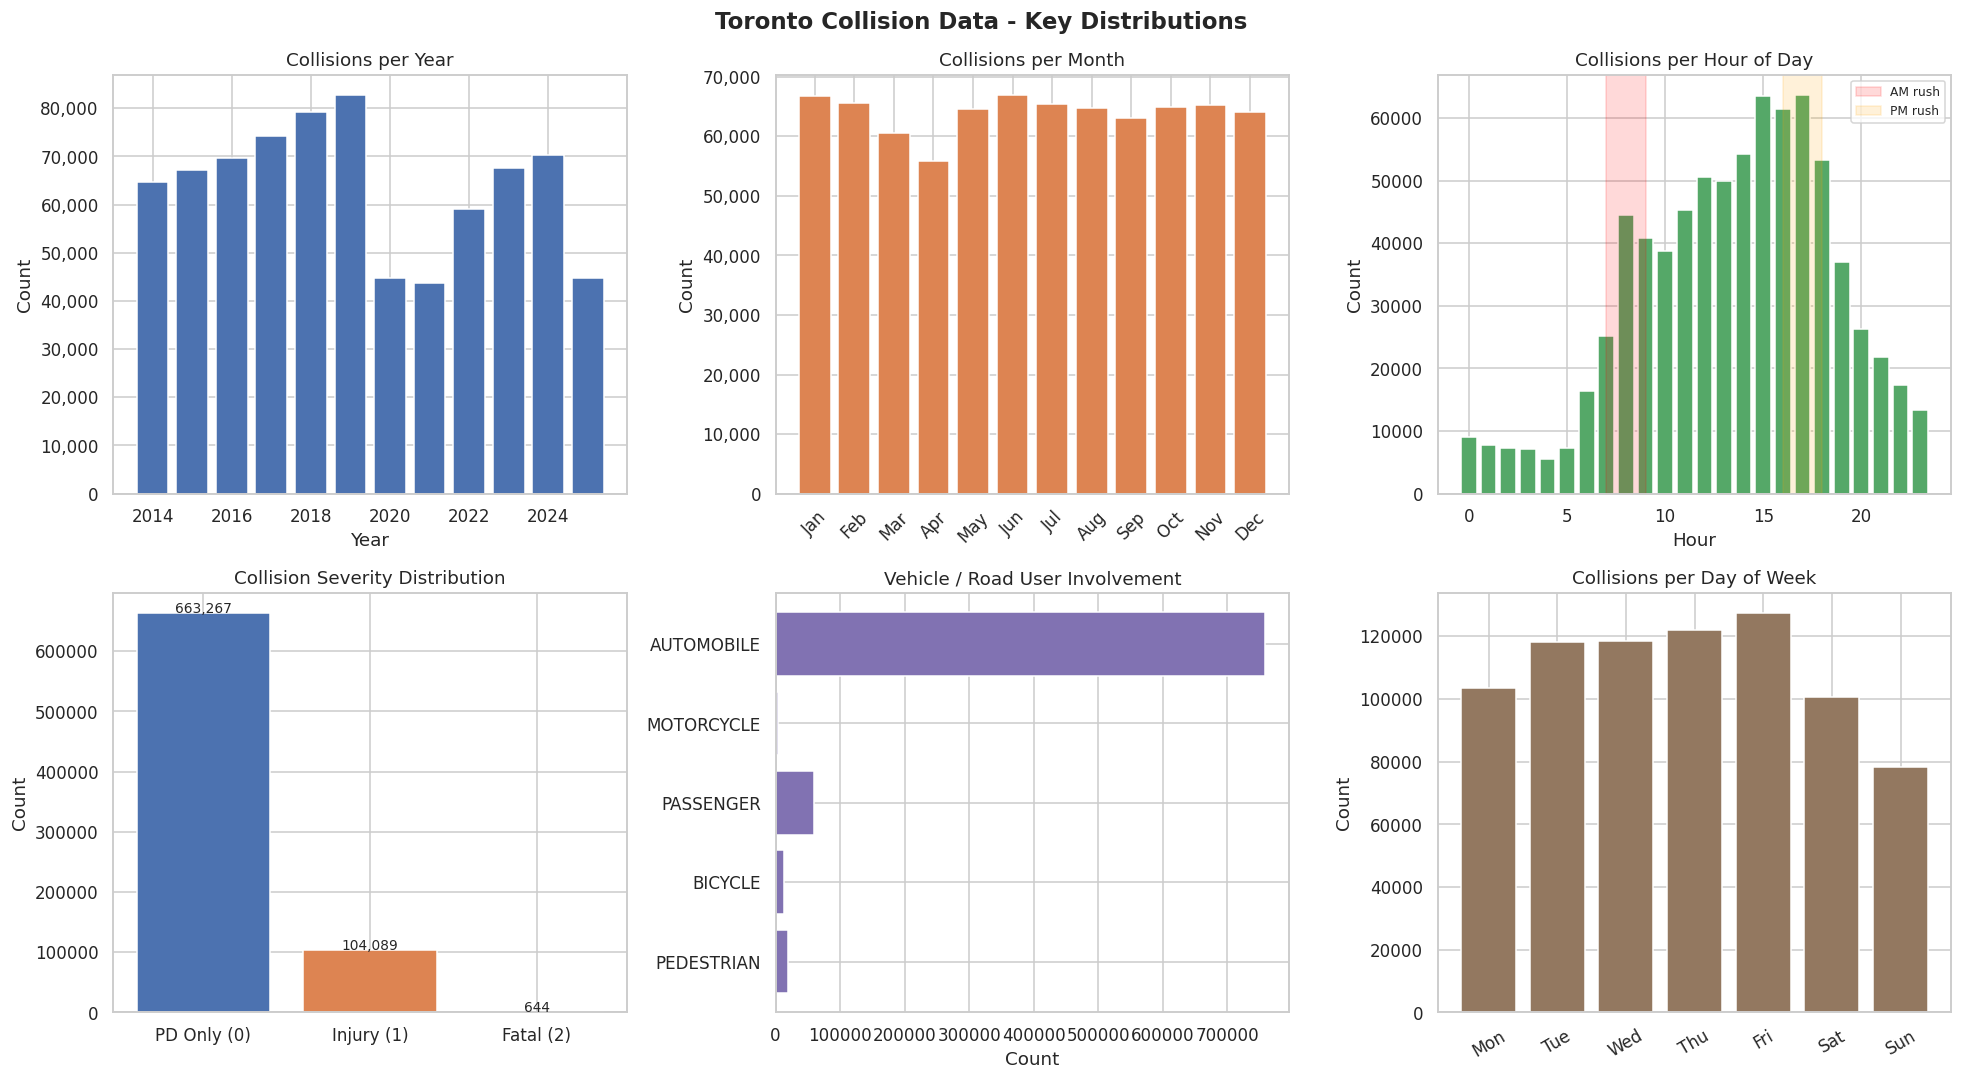

In [7]:
# ── Distribution plots (6 panels) ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Toronto Collision Data - Key Distributions", fontsize=15, fontweight="bold")

# 1. Collisions per year
ax = axes[0, 0]
yr = df_toronto["OCC_YEAR"].value_counts().sort_index()
ax.bar(yr.index, yr.values, color="#4C72B0")
ax.set_title("Collisions per Year")
ax.set_xlabel("Year"); ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 2. Collisions per month
ax = axes[0, 1]
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
mo = df_toronto["OCC_MONTH"].value_counts().reindex(month_order, fill_value=0)
ax.bar(range(12), mo.values, color="#DD8452")
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax.set_title("Collisions per Month"); ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 3. Collisions per hour
ax = axes[0, 2]
hr_col = "OCC_HOUR" if "OCC_HOUR" in df_toronto.columns else "HOUR"
hr = pd.to_numeric(df_toronto[hr_col], errors="coerce").dropna().astype(int)
hr_counts = hr.value_counts().sort_index()
ax.bar(hr_counts.index, hr_counts.values, color="#55A868")
ax.set_title("Collisions per Hour of Day"); ax.set_xlabel("Hour"); ax.set_ylabel("Count")
ax.axvspan(7, 9, alpha=0.15, color="red", label="AM rush")
ax.axvspan(16, 18, alpha=0.15, color="orange", label="PM rush")
ax.legend(fontsize=8)

# 4. SEVERITY breakdown
ax = axes[1, 0]
sev = df_toronto["SEVERITY"].value_counts().sort_index()
ax.bar(["PD Only (0)", "Injury (1)", "Fatal (2)"], sev.values,
       color=["#4C72B0", "#DD8452", "#C44E52"])
ax.set_title("Collision Severity Distribution"); ax.set_ylabel("Count")
for i, v in enumerate(sev.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

# 5. Vehicle type involvement
ax = axes[1, 1]
vehicle_cols = [c for c in ["AUTOMOBILE","MOTORCYCLE","PASSENGER","BICYCLE","PEDESTRIAN"]
                if c in df_toronto.columns]
veh_counts = {c: (df_toronto[c].str.upper().str.strip() == "YES").sum()
              for c in vehicle_cols}
ax.barh(list(veh_counts.keys()), list(veh_counts.values()), color="#8172B2")
ax.set_title("Vehicle / Road User Involvement"); ax.set_xlabel("Count")
ax.invert_yaxis()

# 6. Day of week
ax = axes[1, 2]
if "OCC_DOW" in df_toronto.columns:
    dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    dow = df_toronto["OCC_DOW"].value_counts().reindex(dow_order, fill_value=0)
    ax.bar(range(7), dow.values, color="#937860")
    ax.set_xticks(range(7)); ax.set_xticklabels([d[:3] for d in dow_order], rotation=30)
    ax.set_title("Collisions per Day of Week"); ax.set_ylabel("Count")
else:
    ax.text(0.5, 0.5, "OCC_DOW column not found", transform=ax.transAxes,
            ha="center", va="center", fontsize=11, color="gray")
    ax.set_title("Day of Week (unavailable)")

plt.tight_layout()
plt.show()

---

## Section 2b.1 · EDA – UK DfT 2024 Weather & Road Surface Reference

The DfT dataset includes numeric codes for road surface and weather conditions.
We decode them to understand what the **E_index** must distinguish, and to validate
the CNN road-surface label scheme.

| Code | Road Surface | | Code | Weather |
|---|---|---|---|---|
| 1 | Dry | | 1 | Fine – no wind |
| 2 | Wet / Damp | | 2 | Raining |
| 3 | Snow | | 3 | Snowing |
| 4 | Frost / Ice | | 4 | Fine + high winds |
| 5 | Flood | | 5 | Raining + high winds |
| | | | 6 | Snowing + high winds |
| | | | 7 | Fog / Mist |

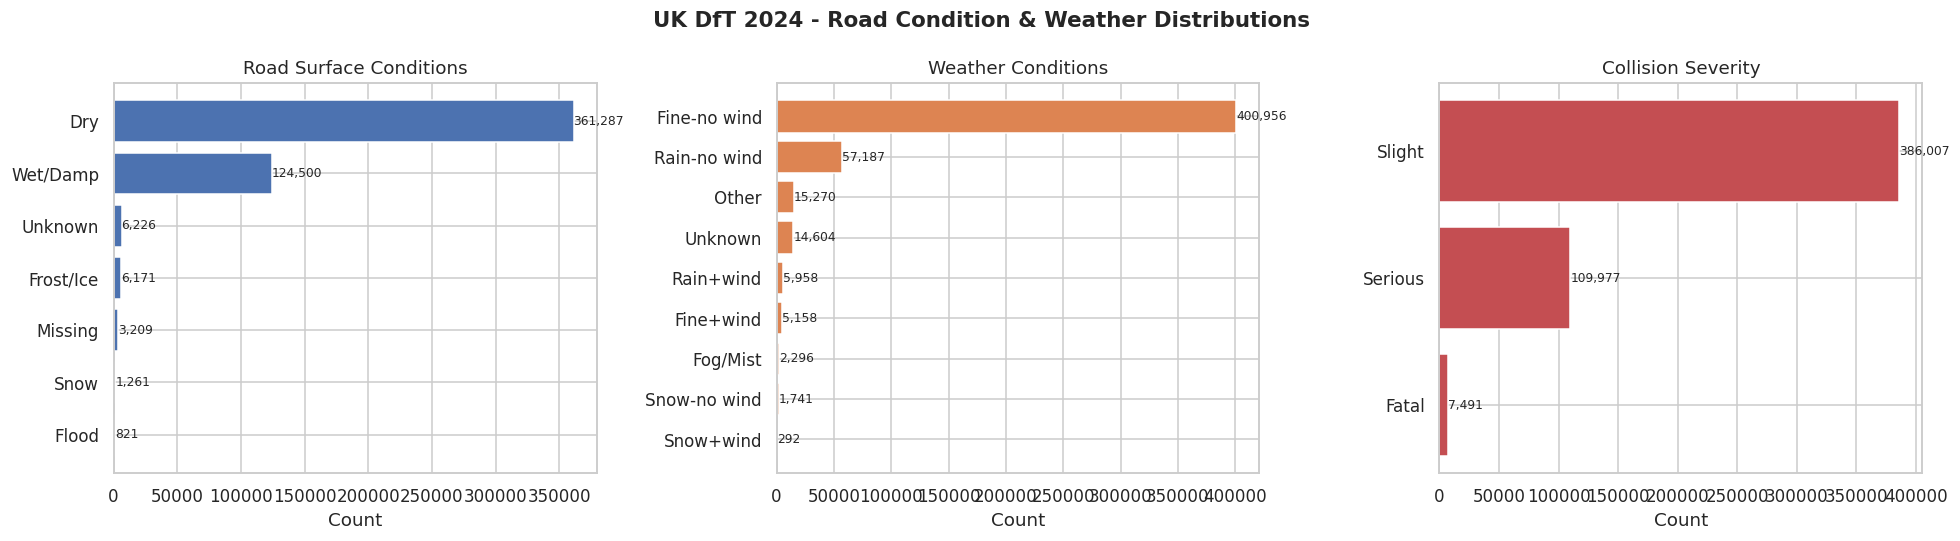


Severity x Road Surface (% of each surface that is Fatal/Serious):
sev_label  Fatal  Serious  Slight
rsc_label                        
Dry          1.4     22.0    76.6
Flood        2.7     22.8    74.5
Frost/Ice    1.2     21.1    77.7
Missing      0.4     11.5    88.1
Snow         1.0     20.7    78.4
Unknown      0.0      6.8    93.2
Wet/Damp     1.8     22.5    75.7


In [8]:
# ── Decode DfT codes and plot distributions ───────────────────────────────────
RSC_MAP     = {1:"Dry", 2:"Wet/Damp", 3:"Snow", 4:"Frost/Ice",
               5:"Flood", 9:"Unknown", -1:"Missing"}
WEATHER_MAP = {1:"Fine-no wind", 2:"Rain-no wind", 3:"Snow-no wind",
               4:"Fine+wind", 5:"Rain+wind", 6:"Snow+wind",
               7:"Fog/Mist", 8:"Other", 9:"Unknown"}
SEV_MAP     = {1:"Fatal", 2:"Serious", 3:"Slight"}

dft["rsc_label"]     = dft["road_surface_conditions"].map(RSC_MAP)
dft["weather_label"] = dft["weather_conditions"].map(WEATHER_MAP)
dft["sev_label"]     = dft["collision_severity"].map(SEV_MAP)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UK DfT 2024 - Road Condition & Weather Distributions",
             fontsize=14, fontweight="bold")

for ax, col, title, color in [
    (axes[0], "rsc_label",     "Road Surface Conditions", "#4C72B0"),
    (axes[1], "weather_label", "Weather Conditions",       "#DD8452"),
    (axes[2], "sev_label",     "Collision Severity",       "#C44E52"),
]:
    vc = dft[col].value_counts()
    ax.barh(vc.index, vc.values, color=color)
    ax.set_title(title); ax.set_xlabel("Count")
    ax.invert_yaxis()
    for i, v in enumerate(vc.values):
        ax.text(v + 20, i, f"{v:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Cross-tab: severity vs road surface
print("\nSeverity x Road Surface (% of each surface that is Fatal/Serious):")
ct = pd.crosstab(dft["rsc_label"], dft["sev_label"], normalize="index").round(3) * 100
print(ct.to_string())

## Section 2b.2 · EDA – Seattle SDOT collision data


In [9]:
# Convert date to datetime and filter for the last five years
sdot['INCDTTM'] = pd.to_datetime(sdot['INCDTTM'], errors='coerce')
sdot['OCC_YEAR'] = sdot['INCDTTM'].dt.year
sdot_filtered = sdot[sdot['OCC_YEAR'] >= 2021].copy()

print(f"Last 5 years sdot        : {sdot_filtered.shape[0]:,} rows x {sdot_filtered.shape[1]} cols")
print("Data Shape:", sdot_filtered.shape, "\n")

print("-- Infos for each column --")
print(sdot_filtered.dtypes.to_string(),"\n")


Last 5 years sdot        : 28,629 rows x 67 cols
Data Shape: (28629, 67) 

-- Infos for each column --
OBJECTID                                   int64
SE_ANNO_CAD_DATA                          object
INCKEY                                     int64
COLDETKEY                                  int64
REPORTNO                                  object
STATUS                                    object
ADDRTYPE                                  object
INTKEY                                   float64
LOCATION                                  object
EXCEPTRSNCODE                             object
EXCEPTRSNDESC                             object
PERSONCOUNT                                int64
PEDCOUNT                                   int64
PEDCYLCOUNT                                int64
VEHCOUNT                                   int64
INJURIES                                   int64
SERIOUSINJURIES                            int64
FATALITIES                                 int64
INCDATE        

### Target Variable Engineering
Dataset contains multiple columns for collision results.

We combine these into a single `SEVERITY`' column.

`2`:  **Fatal**, while `FATALITIES > 0`

`1`:  **Injury**, while `INJURY_COLLISIONS == YES`

`0`:  **Property Damage Only**

In [10]:
# Convert SEVERITY to numerical value
def assign_sdot_severity(row):
    if str(row.get("FATALITY", "")).strip().upper() == "Y":
        return 2
    if str(row.get("SERIOUSINJURY", "")).strip().upper() == "Y" or str(row.get("NONSERIOUSINJURY", "")).strip().upper() == "Y":
        return 1
    return 0

sdot_filtered["SEVERITY"] = sdot_filtered.apply(assign_sdot_severity, axis=1)

print("SEVERITY distribution on sdot:")
counts_sdot = sdot_filtered["SEVERITY"].value_counts().sort_index()
labels_sdot = {0: "0: PD Only", 1: "1: Injury", 2: "2: Fatal"}
for k, v in counts_sdot.items():
    print(f"  {labels_sdot[k]:18s}  {v:>7,}  ({v/len(sdot_filtered)*100:.2f}%)")



SEVERITY distribution on sdot:
  0: PD Only           17,658  (61.68%)
  1: Injury            10,826  (37.81%)
  2: Fatal                145  (0.51%)


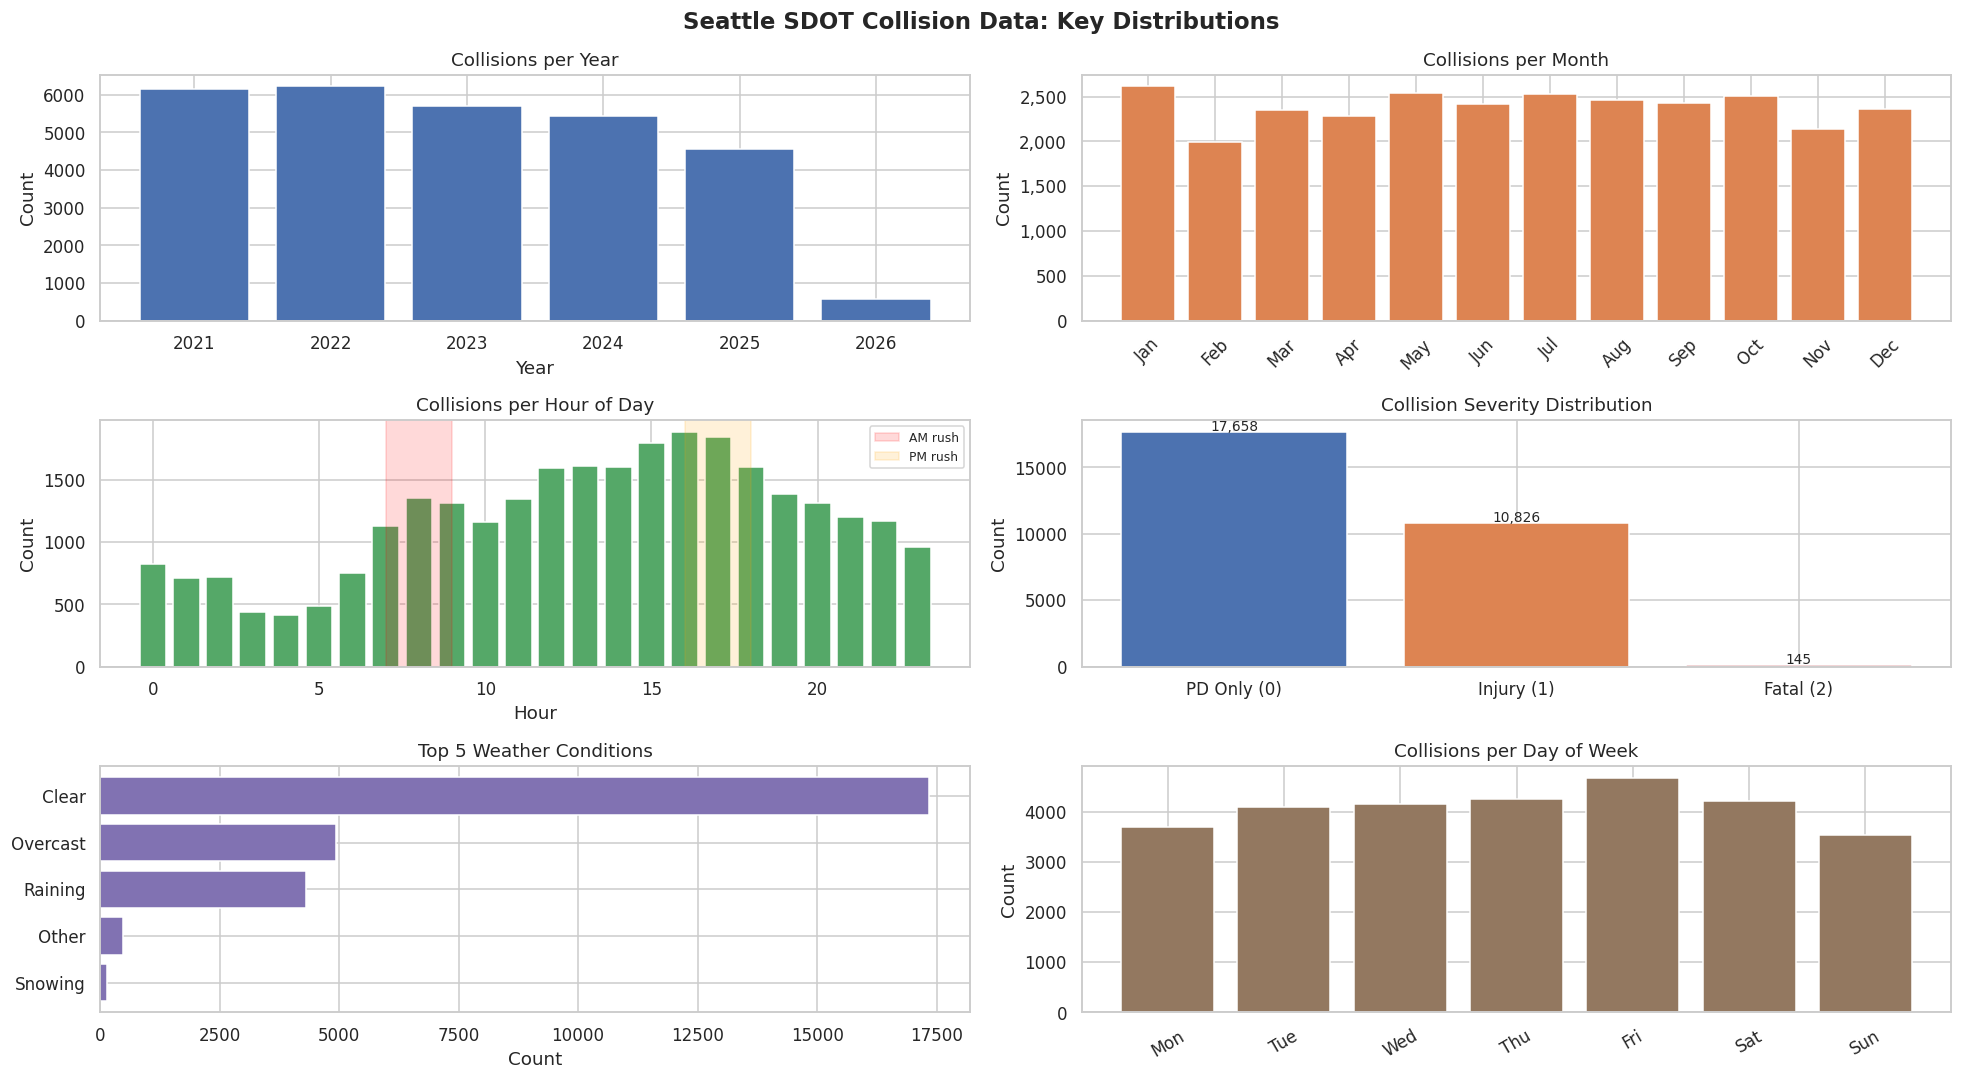

In [11]:
# Extract additional time features for visualization
sdot_filtered['OCC_MONTH'] = sdot_filtered['INCDTTM'].dt.month_name()
sdot_filtered['OCC_HOUR'] = sdot_filtered['INCDTTM'].dt.hour
sdot_filtered['OCC_DOW'] = sdot_filtered['INCDTTM'].dt.day_name()

# Plots into 3 by 2 panels
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
fig.suptitle("Seattle SDOT Collision Data: Key Distributions", fontsize=15, fontweight="bold")

# Chart 1: Collisions per year
ax = axes[0, 0]
yr = sdot_filtered["OCC_YEAR"].value_counts().sort_index()
ax.bar(yr.index, yr.values, color="#4C72B0")
ax.set_title("Collisions per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Chart 2: Collisions per month
ax = axes[0, 1]
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
mo = sdot_filtered["OCC_MONTH"].value_counts().reindex(month_order, fill_value=0)
ax.bar(range(12), mo.values, color="#DD8452")
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax.set_title("Collisions per Month")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Chart 3: Collisions per hour
ax = axes[1, 0]
hr_counts = sdot_filtered["OCC_HOUR"].value_counts().sort_index()
ax.bar(hr_counts.index, hr_counts.values, color="#55A868")
ax.set_title("Collisions per Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Count")
ax.axvspan(7, 9, alpha=0.15, color="red", label="AM rush")
ax.axvspan(16, 18, alpha=0.15, color="orange", label="PM rush")
ax.legend(fontsize=8)

# Chart 4: SEVERITY breakdown
ax = axes[1, 1]
sev = sdot_filtered["SEVERITY"].value_counts().sort_index()
ax.bar(["PD Only (0)", "Injury (1)", "Fatal (2)"], sev.values,
       color=["#4C72B0", "#DD8452", "#C44E52"])
ax.set_title("Collision Severity Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(sev.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

# Chart 5: Weather conditions
ax = axes[2, 0]
if "WEATHER" in sdot_filtered.columns:
    weather_counts = sdot_filtered["WEATHER"].value_counts().head(5)
    ax.barh(weather_counts.index, weather_counts.values, color="#8172B2")
    ax.set_title("Top 5 Weather Conditions")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, "WEATHER column not found", transform=ax.transAxes, ha="center", va="center", color="gray")

# Chart 6: Day of week
ax = axes[2, 1]
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = sdot_filtered["OCC_DOW"].value_counts().reindex(dow_order, fill_value=0)
ax.bar(range(7), dow.values, color="#937860")
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in dow_order], rotation=30)
ax.set_title("Collisions per Day of Week")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Section 2b.3 · EDA – Merged Last 5 years UK and SDOT Dataset


In [12]:
# Define the columns to extract based on the paper
uk_features = [
    'date', 'time', 'collision_severity', 'road_surface_conditions',
    'light_conditions', 'weather_conditions', 'junction_detail'
]

sdot_features = [
    'INCDATE', 'INCDTTM', 'SEVERITYCODE', 'ROADCOND',
    'LIGHTCOND', 'WEATHER', 'JUNCTIONTYPE'
]

# Create new dataframes with only the selected features
dft_subset = dft[uk_features].copy()
sdot_subset = sdot_filtered[sdot_features].copy()

# Define mapping dictionaries to standardize column names
rename_uk = {
    'date': 'Date',
    'time': 'Time',
    'collision_severity': 'Severity',
    'road_surface_conditions': 'Road_Condition',
    'light_conditions': 'Light_Condition',
    'weather_conditions': 'Weather',
    'junction_detail': 'Junction_Type'
}

rename_sdot = {
    'INCDATE': 'Date',
    'INCTIME': 'Time',
    'SEVERITYCODE': 'Severity',
    'ROADCOND': 'Road_Condition',
    'LIGHTCOND': 'Light_Condition',
    'WEATHER': 'Weather',
    'JUNCTIONTYPE': 'Junction_Type'
}

# Rename the columns
dft_subset.rename(columns=rename_uk, inplace=True)
sdot_subset.rename(columns=rename_sdot, inplace=True)

# Verify the extraction and alignment
print("UK Dataset Features:")
print(dft_subset.head())

print("\nSDOT Dataset Features:")
print(sdot_subset.head())

UK Dataset Features:
         Date   Time  Severity  Road_Condition  Light_Condition  Weather  \
0  22/05/2021  22:44         3               1                6        1   
1  20/10/2021  15:50         3               1                1        1   
2  01/12/2020  18:00         3               1                4        1   
3  09/12/2021  16:55         3               2                4        1   
4  12/04/2021  09:02         3               1                1        1   

   Junction_Type  
0              0  
1             16  
2             16  
3              0  
4              0  

SDOT Dataset Features:
              Date             INCDTTM  Severity Road_Condition  \
27  2/16/2024 0:00 2024-02-16 16:00:00       1.0            Dry   
32  10/2/2023 0:00 2023-10-02 21:18:00       2.0            Wet   
38  9/29/2023 0:00 2023-09-29 16:45:00       2.0            Dry   
44  11/9/2023 0:00 2023-11-09 22:09:00       2.0            NaN   
63  10/3/2023 0:00 2023-10-03 15:02:00       1.0 

In [13]:
import pandas as pd

# 1. Define mapping rules for SDOT text to numbers based on the table
dict_road = {'Dry': 1, 'Wet': 2, 'Snow/Slush': 3, 'Ice': 4, 'Standing Water': 5, 'Oil': 6, 'Sand/Mud/Dirt': 7}
dict_light = {'Daylight': 1, 'Dusk': 2, 'Dawn': 3, 'Dark - Street Lights On': 4, 'Dark - Street Lights Off': 5, 'Dark - No Street Lights': 6}
dict_weather = {'Clear': 1, 'Raining': 2, 'Snowing': 3, 'Fog/Smog/Smoke': 4, 'Severe Crosswind': 5, 'Blowing Sand/Dirt': 6, 'Unknown': 7}
dict_junc = {
    'At Intersection (intersection related)': 1,
    'At Intersection (but not related to intersection)': 1,
    'Mid-Block (not related to intersection)': 2,
    'Mid-Block (but intersection related)': 2,
    'Driveway Junction': 3,
    'Ramp Junction': 4
}

# Apply mappings to SDOT data
sdot_subset['Road_Condition'] = sdot_subset['Road_Condition'].map(dict_road).fillna(0)
sdot_subset['Light_Condition'] = sdot_subset['Light_Condition'].map(dict_light).fillna(0)
sdot_subset['Weather'] = sdot_subset['Weather'].map(dict_weather).fillna(0)
sdot_subset['Junction_Type'] = sdot_subset['Junction_Type'].map(dict_junc).fillna(0)

# SDOT severity scales usually have 1, 2, 2b, 3. The map aligns them to 1 (slight), 2 (serious), 3 (fatal).
dict_sdot_sev = {1.0: 0, 2.0: 0, '2b': 1, 3.0: 2}
sdot_subset['Severity'] = sdot_subset['Severity'].map(dict_sdot_sev).fillna(1)

# Extract time from INCDTTM and drop the extra column
if 'INCDTTM' in sdot_subset.columns:
    sdot_subset['Time'] = pd.to_datetime(sdot_subset['INCDTTM'], errors='coerce').dt.time
    sdot_subset = sdot_subset.drop(columns=['INCDTTM'])

# 2. Adjust UK severity to match the table
# The UK uses 1 for fatal and 3 for slight. The table wants 1 for slight and 3 for fatal.
dict_uk_sev = {3: 0, 2: 1, 1: 2}
dft_subset['Severity'] = dft_subset['Severity'].map(dict_uk_sev)

# Standardize date formats for both datasets
dft_subset['Date'] = pd.to_datetime(dft_subset['Date'], format='%d/%m/%Y', errors='coerce')
sdot_subset['Date'] = pd.to_datetime(sdot_subset['Date'], errors='coerce')

# 3. Merge both datasets together
merged_data = pd.concat([dft_subset, sdot_subset], ignore_index=True)

# Drop rows with missing values to ensure models train properly
merged_uk_sdot = merged_data.dropna()

print("Merged Dataset Preview:")
print(merged_uk_sdot.sample(5))
print("\nTotal shape after merging and cleaning:")
print(merged_uk_sdot.shape)



Merged Dataset Preview:
             Date      Time  Severity  Road_Condition  Light_Condition  \
296561 2023-04-24     10:50       0.0             2.0              1.0   
271279 2024-06-19     22:47       0.0             1.0              4.0   
463094 2020-01-31     17:12       0.0             2.0              4.0   
233644 2022-08-25     08:24       0.0             2.0              1.0   
529742 2023-05-13  17:23:00       0.0             1.0              1.0   

        Weather  Junction_Type  
296561      2.0           13.0  
271279      1.0           13.0  
463094      2.0           16.0  
233644      2.0           19.0  
529742      1.0            1.0  

Total shape after merging and cleaning:
(532104, 7)


In [14]:
# Show SEVERITY distribution
print("SEVERITY distribution:")
counts_merged = merged_uk_sdot['Severity'].value_counts()
labels_merged = {0: "0: PD Only", 1: "1: Injury", 2: "2: Fatal"}

for k, v in counts_merged.items():
    print(f"  {labels_merged[k]:18s}  {v:>7,}  ({v/len(merged_uk_sdot)*100:.2f}%)")



SEVERITY distribution:
  0: PD Only          413,301  (77.67%)
  1: Injury           110,145  (20.70%)
  2: Fatal              8,658  (1.63%)


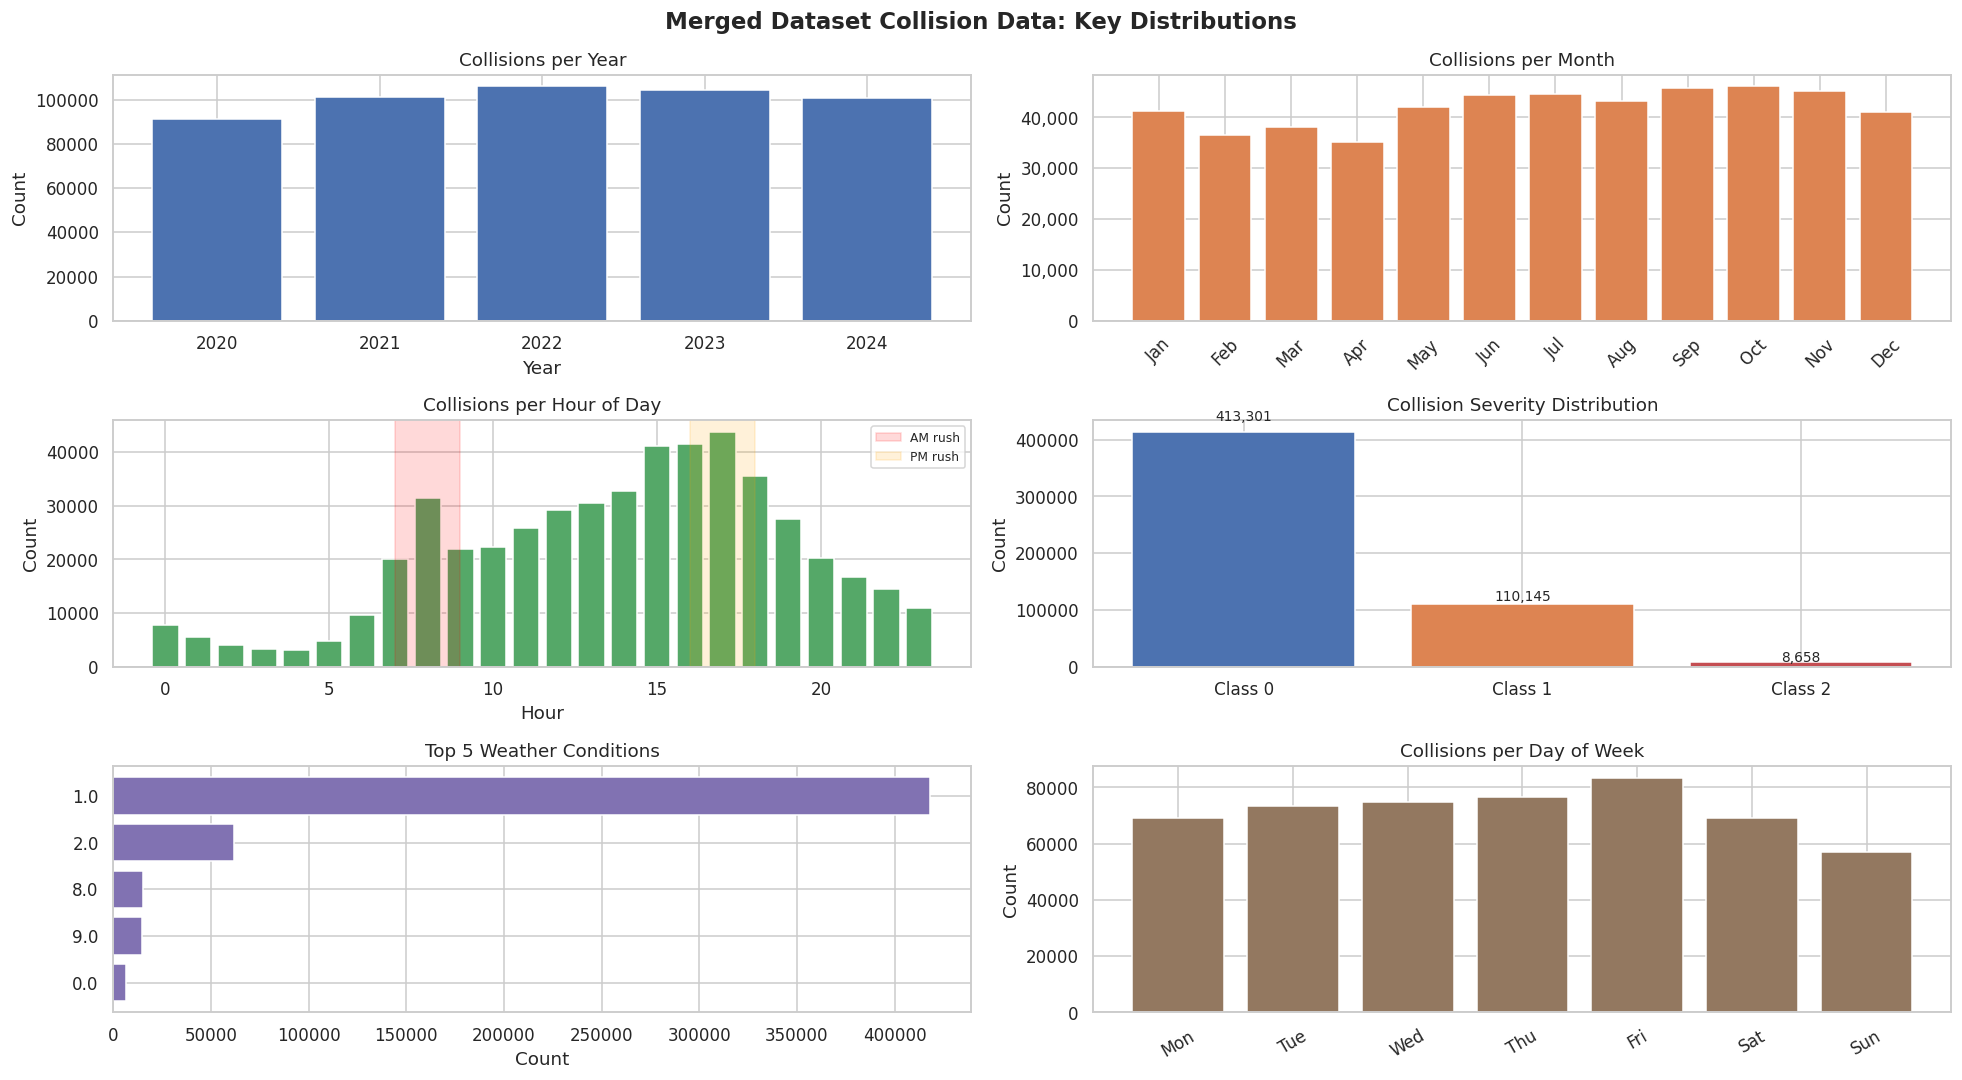

In [15]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as mticker

# Merge Date and Time to extract features
merged_uk_sdot['Datetime'] = pd.to_datetime(merged_uk_sdot['Date'].astype(str) + ' ' + merged_uk_sdot['Time'].astype(str), errors='coerce')

merged_uk_sdot['OCC_YEAR'] = merged_uk_sdot['Datetime'].dt.year
merged_uk_sdot['OCC_MONTH'] = merged_uk_sdot['Datetime'].dt.month_name()
merged_uk_sdot['OCC_HOUR'] = merged_uk_sdot['Datetime'].dt.hour
merged_uk_sdot['OCC_DOW'] = merged_uk_sdot['Datetime'].dt.day_name()

# Plots into 3 by 2 panels
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
fig.suptitle("Merged Dataset Collision Data: Key Distributions", fontsize=15, fontweight="bold")

# Chart 1: Collisions per year
ax = axes[0, 0]
yr = merged_uk_sdot["OCC_YEAR"].value_counts().sort_index()
ax.bar(yr.index, yr.values, color="#4C72B0")
ax.set_title("Collisions per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Chart 2: Collisions per month
ax = axes[0, 1]
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
mo = merged_uk_sdot["OCC_MONTH"].value_counts().reindex(month_order, fill_value=0)
ax.bar(range(12), mo.values, color="#DD8452")
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax.set_title("Collisions per Month")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Chart 3: Collisions per hour
ax = axes[1, 0]
hr_counts = merged_uk_sdot["OCC_HOUR"].value_counts().sort_index()
ax.bar(hr_counts.index, hr_counts.values, color="#55A868")
ax.set_title("Collisions per Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Count")
ax.axvspan(7, 9, alpha=0.15, color="red", label="AM rush")
ax.axvspan(16, 18, alpha=0.15, color="orange", label="PM rush")
ax.legend(fontsize=8)

# Chart 4: SEVERITY breakdown
ax = axes[1, 1]
sev = merged_uk_sdot["Severity"].value_counts().sort_index()
labels = [f"Class {int(idx)}" for idx in sev.index]
ax.bar(labels, sev.values, color=["#4C72B0", "#DD8452", "#C44E52"][:len(sev)])
ax.set_title("Collision Severity Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(sev.values):
    ax.text(i, v + (v * 0.05), f"{v:,}", ha="center", fontsize=9)

# Chart 5: Weather conditions
ax = axes[2, 0]
if "Weather" in merged_uk_sdot.columns:
    weather_counts = merged_uk_sdot["Weather"].value_counts().head(5)
    ax.barh([str(idx) for idx in weather_counts.index], weather_counts.values, color="#8172B2")
    ax.set_title("Top 5 Weather Conditions")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, "Weather column not found", transform=ax.transAxes, ha="center", va="center", color="gray")

# Chart 6: Day of week
ax = axes[2, 1]
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = merged_uk_sdot["OCC_DOW"].value_counts().reindex(dow_order, fill_value=0)
ax.bar(range(7), dow.values, color="#937860")
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in dow_order], rotation=30)
ax.set_title("Collisions per Day of Week")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

---

## Section 2c · Summary Statistics – Replicating Paper 2 on Our Data

Jiang et al. (2024) reported mean casualties per collision under each environmental
condition on the combined SDOT+DfT dataset.  We reproduce those tables on our
**DfT 2024** slice to:
1. Validate data consistency with the published paper.
2. Calibrate E_index weights for the Safety Score.
3. Quantify excess casualty % per hazard type.

**Paper 2 headline benchmarks:**
- Snowing road surface: **+10.75%** excess casualties
- Standing water: **+10.44%**
- Dusk / insufficient lighting: **+13.01%**

In [16]:
# ── Reproduce Paper 2 summary tables (Tables 2, 3, 4) ────────────────────────
WEATHER_LABELS = {1:"Fine/Clear", 2:"Raining", 3:"Snowing", 4:"Fine+Wind",
                  5:"Raining+Wind", 6:"Snowing+Wind", 7:"Fog/Mist"}
RSC_LABELS     = {1:"Dry", 2:"Wet/Damp", 3:"Snow/Slush",
                  4:"Ice/Frost", 5:"Flood/Standing Water"}
LIGHT_LABELS   = {1:"Daylight", 2:"Darkness-Lit", 3:"Darkness-Unlit",
                  4:"Darkness-NoLight", 5:"Dusk", 6:"Dawn"}

dft_stats = dft[["weather_conditions","road_surface_conditions","light_conditions",
                  "collision_severity","number_of_casualties","number_of_vehicles"]].copy()

dft_stats = dft_stats[
    dft_stats["weather_conditions"].isin(WEATHER_LABELS.keys()) &
    dft_stats["road_surface_conditions"].isin(RSC_LABELS.keys()) &
    dft_stats["light_conditions"].isin(LIGHT_LABELS.keys())
].copy()

dft_stats["weather_label"] = dft_stats["weather_conditions"].map(WEATHER_LABELS)
dft_stats["rsc_label"]     = dft_stats["road_surface_conditions"].map(RSC_LABELS)
dft_stats["light_label"]   = dft_stats["light_conditions"].map(LIGHT_LABELS)

def summary_table(df, group_col, label=""):
    return (df.groupby(group_col)
              .agg(Mean_Persons =("number_of_casualties","mean"),
                   Mean_Vehicles=("number_of_vehicles","mean"),
                   Count        =("number_of_casualties","size"))
              .sort_values("Mean_Persons", ascending=False)
              .round(3))

tbl_weather = summary_table(dft_stats, "weather_label")
tbl_rsc     = summary_table(dft_stats, "rsc_label")
tbl_light   = summary_table(dft_stats, "light_label")

print(f"Filtered rows: {len(dft_stats):,}")
print("\n=== TABLE A: Weather vs. Mean Casualties (Paper 2 Table 2) ===")
print(tbl_weather.to_string())
print("\n=== TABLE B: Road Surface vs. Mean Casualties (Paper 2 Table 3) ===")
print(tbl_rsc.to_string())
print("\n=== TABLE C: Lighting vs. Mean Casualties (Paper 2 Table 4) ===")
print(tbl_light.to_string())

Filtered rows: 463,755

=== TABLE A: Weather vs. Mean Casualties (Paper 2 Table 2) ===
               Mean_Persons  Mean_Vehicles   Count
weather_label                                     
Snowing+Wind          1.374          1.709     289
Fog/Mist              1.351          1.735    2207
Raining+Wind          1.340          1.694    5759
Snowing               1.313          1.784    1691
Fine+Wind             1.302          1.760    5059
Raining               1.302          1.787   55554
Fine/Clear            1.276          1.844  393196

=== TABLE B: Road Surface vs. Mean Casualties (Paper 2 Table 3) ===
                      Mean_Persons  Mean_Vehicles   Count
rsc_label                                                
Flood/Standing Water         1.412          1.453     786
Snow/Slush                   1.342          1.796    1183
Wet/Damp                     1.315          1.796  115464
Ice/Frost                    1.293          1.664    4517
Dry                          1.268   

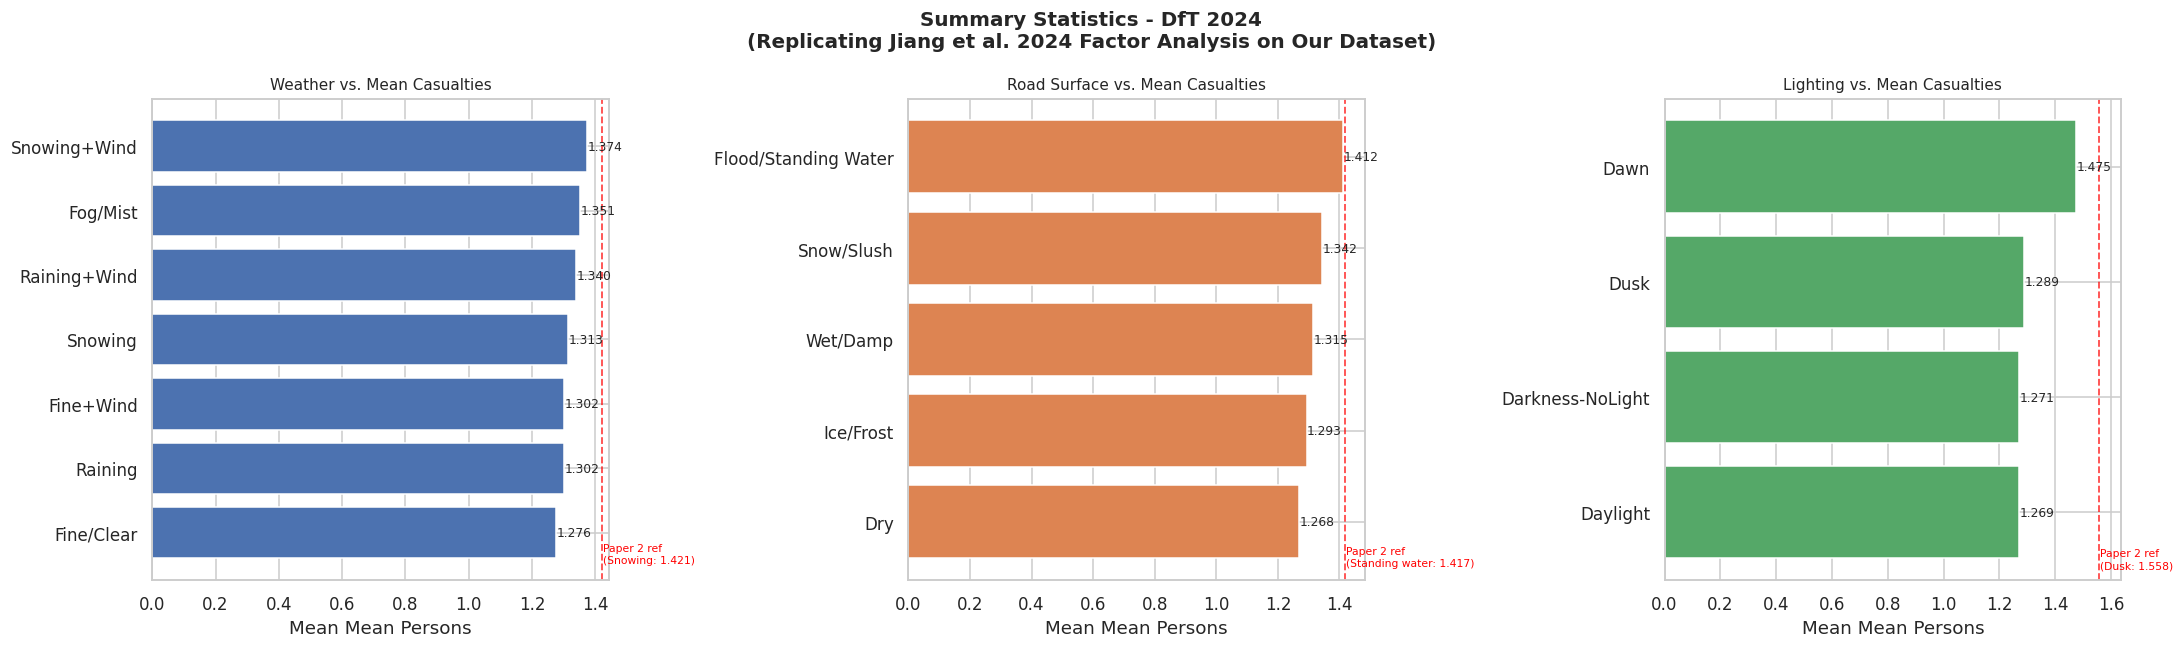

In [17]:
# ── Visualise Tables A / B / C with Paper 2 reference lines ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Summary Statistics - DfT 2024\n"
             "(Replicating Jiang et al. 2024 Factor Analysis on Our Dataset)",
             fontsize=13, fontweight="bold")

def bar_ref(ax, df, col, title, ref_label=None, ref_val=None, color="#4C72B0"):
    vals   = df[col].values
    labels = df.index.tolist()
    bars   = ax.barh(labels, vals, color=color)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Mean " + col.replace("_", " "))
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)
    if ref_val is not None:
        ax.axvline(ref_val, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
        ax.text(ref_val + 0.003, len(df) - 0.5,
                f"Paper 2 ref\n({ref_label}: {ref_val})",
                color="red", fontsize=7, va="bottom")

bar_ref(axes[0], tbl_weather, "Mean_Persons", "Weather vs. Mean Casualties",
        ref_label="Snowing", ref_val=1.421, color="#4C72B0")
bar_ref(axes[1], tbl_rsc,     "Mean_Persons", "Road Surface vs. Mean Casualties",
        ref_label="Standing water", ref_val=1.417, color="#DD8452")
bar_ref(axes[2], tbl_light,   "Mean_Persons", "Lighting vs. Mean Casualties",
        ref_label="Dusk", ref_val=1.558, color="#55A868")

plt.tight_layout()
plt.show()

In [18]:
# ── Excess casualties above average (replicating Paper 2 headline stats) ──────
overall_mean = dft_stats["number_of_casualties"].mean()
print(f"Overall mean casualties per collision: {overall_mean:.4f}\n")

hazards = {
    "Snow/Slush (road)":      dft_stats[dft_stats["road_surface_conditions"]==3]["number_of_casualties"].mean(),
    "Ice/Frost (road)":       dft_stats[dft_stats["road_surface_conditions"]==4]["number_of_casualties"].mean(),
    "Flood/Standing Water":   dft_stats[dft_stats["road_surface_conditions"]==5]["number_of_casualties"].mean(),
    "Snowing (weather)":      dft_stats[dft_stats["weather_conditions"]==3]["number_of_casualties"].mean(),
    "Snowing+Wind (weather)": dft_stats[dft_stats["weather_conditions"]==6]["number_of_casualties"].mean(),
    "Fog/Mist (weather)":     dft_stats[dft_stats["weather_conditions"]==7]["number_of_casualties"].mean(),
    "Darkness-No Lighting":   dft_stats[dft_stats["light_conditions"]==4]["number_of_casualties"].mean(),
    "Dusk":                   dft_stats[dft_stats["light_conditions"]==5]["number_of_casualties"].mean(),
}

print(f"{'Condition':<30} {'Mean':>8}  {'Excess':>10}   Paper 2 ref")
print("-" * 70)
refs = {"Dusk": "+13.01%", "Snow/Slush (road)": "+10.75%",
        "Flood/Standing Water": "+10.44%"}
for name, val in sorted(hazards.items(), key=lambda x: -x[1]):
    excess = (val - overall_mean) / overall_mean * 100
    ref    = refs.get(name, "")
    print(f"{name:<30} {val:>8.4f}  {excess:>+10.2f}%   {ref}")

print()
print("Paper 2 benchmarks (SDOT+DfT combined):")
print("  Snowy surface +10.75%  |  Standing water +10.44%  |  Dusk +13.01%")

Overall mean casualties per collision: 1.2806

Condition                          Mean      Excess   Paper 2 ref
----------------------------------------------------------------------
Flood/Standing Water             1.4122      +10.28%   +10.44%
Snowing+Wind (weather)           1.3737       +7.27%   
Fog/Mist (weather)               1.3512       +5.51%   
Snow/Slush (road)                1.3423       +4.82%   +10.75%
Snowing (weather)                1.3128       +2.51%   
Ice/Frost (road)                 1.2931       +0.98%   
Dusk                             1.2892       +0.67%   +13.01%
Darkness-No Lighting             1.2711       -0.74%   

Paper 2 benchmarks (SDOT+DfT combined):
  Snowy surface +10.75%  |  Standing water +10.44%  |  Dusk +13.01%


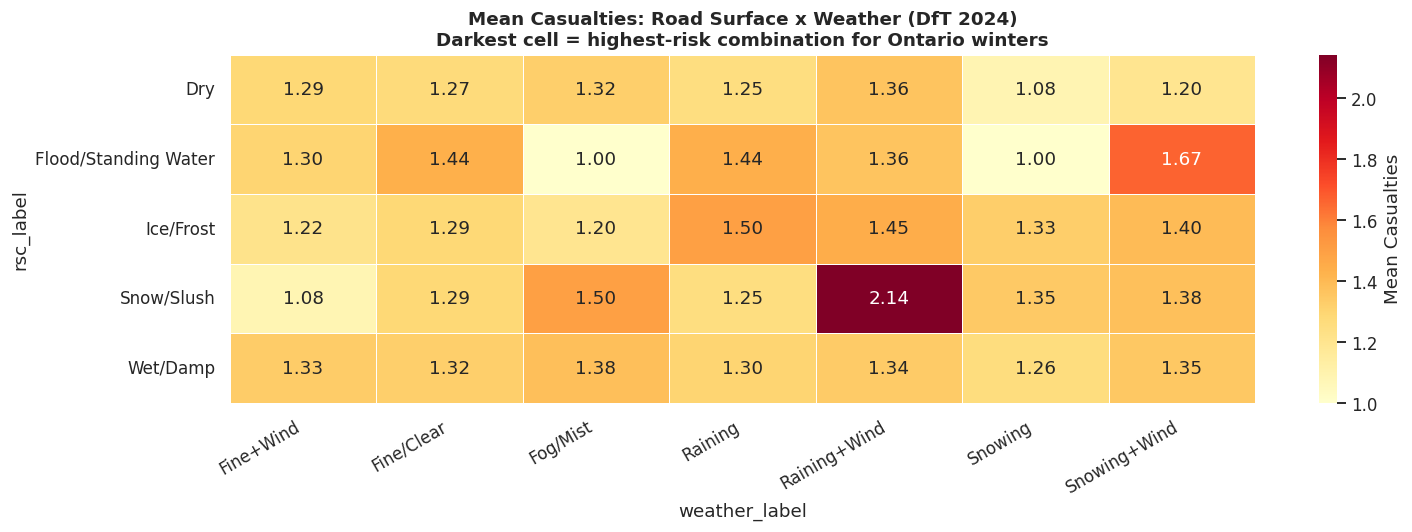

Key insight: Snow/Slush x Snowing+Wind is the highest-risk combination.
  This directly calibrates the E_index for Ontario winter conditions.


In [19]:
# ── Road Surface x Weather heatmap ────────────────────────────────────────────
pivot = dft_stats.pivot_table(
    index="rsc_label", columns="weather_label",
    values="number_of_casualties", aggfunc="mean"
).round(3)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Mean Casualties"})
plt.title("Mean Casualties: Road Surface x Weather (DfT 2024)\n"
          "Darkest cell = highest-risk combination for Ontario winters",
          fontsize=12, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print("Key insight: Snow/Slush x Snowing+Wind is the highest-risk combination.")
print("  This directly calibrates the E_index for Ontario winter conditions.")

---

## Section 2d · Safety Score Design – Informed by Paper 1 (SPI)

### From Seakeeping Performance Index to Safety Score S

Paper 1 (Pennino & D'Amato, 2024) defines a composite **SPI** clamped to [0,1]
from 6 normalised safety criteria. Our **Safety Score S** follows the same structure
adapted for highway road conditions:

$$S = (w_T \cdot T_{\text{NLP}}) + (w_V \cdot V_{\text{Vision}}) + (w_E \cdot E_{\text{index}}) \times 100$$

$$E_{\text{index}} = 0.35 \cdot\text{SurfaceRisk} + 0.30 \cdot\text{VisibilityRisk} + 0.20 \cdot\text{WindRisk} + 0.15 \cdot\text{TempRisk}$$

### E_index weights — grounded in Paper 2 excess-casualty analysis

| Component | Paper 2 excess | Weight |
|---|---|---|
| Road surface hazard (snow/ice/flood) | +10.75% | **delta = 0.35** |
| Dusk / darkness (visibility) | +13.01% | **gamma = 0.30** |
| Snowing / blowing snow (wind) | +10.75% | **beta = 0.20** |
| Temperature (freeze risk proxy) | — | **alpha = 0.15** |

| S range | Risk Tier | Action |
|---|---|---|
| 0 – 30 | LOW | Normal operations |
| 31 – 70 | MEDIUM | Reduce speed, increase following distance |
| 71 – 100 | HIGH | Alert dispatcher; consider route diversion |

---

## Section 3 · Data Preprocessing

### 3.1 Toronto Dataset – Steps

| Step | Action | Reason |
|---|---|---|
| 1 | Drop rows missing key flag columns | Only 4 rows (~0.0005%); too few to impute safely |
| 2 | Fix zero coordinates (Gulf of Guinea) | (0,0) is geometrically invalid for Ontario analysis |
| 3 | Binary-encode YES/NO columns | Logistic Regression and RF require numeric input |
| 4 | Month name → numeric | January=1 … December=12 |
| 5 | Add season flag | Ontario winter (Dec–Mar) is the core Smart-Shield hazard period |
| 6 | Add IS_NIGHT and IS_RUSHHOUR | Binary distillations of hour-of-day signal |

In [20]:
# ── Toronto preprocessing (creates df clean, then df_model) ──────────────────
df = df_toronto.dropna(subset=[
    c for c in ["INJURY_COLLISIONS","FTR_COLLISIONS","PD_COLLISIONS",
                "AUTOMOBILE","MOTORCYCLE","PASSENGER","BICYCLE","PEDESTRIAN"]
    if c in df_toronto.columns
]).copy()
print(f"Rows after dropping nulls: {len(df):,}  (from {len(df_toronto):,})")

# Fix invalid coordinates
if "LAT_WGS84" in df.columns:
    df["COORDS_VALID"] = ((df["LAT_WGS84"] != 0) & (df["LONG_WGS84"] != 0)).astype(int)
    df.loc[df["LAT_WGS84"] == 0, ["LAT_WGS84","LONG_WGS84"]] = np.nan
    print(f"Valid GPS coords : {df['COORDS_VALID'].sum():,} / {len(df):,}")

# Binary encode YES/NO
bin_cols = [c for c in ["INJURY_COLLISIONS","FTR_COLLISIONS","PD_COLLISIONS",
                         "AUTOMOBILE","MOTORCYCLE","PASSENGER","BICYCLE","PEDESTRIAN"]
            if c in df.columns]
for col in bin_cols:
    df[col + "_BIN"] = (df[col].astype(str).str.upper().str.strip() == "YES").astype(int)

# Month name -> numeric
MONTH_MAP = {m: i+1 for i, m in enumerate(
    ["January","February","March","April","May","June",
     "July","August","September","October","November","December"])}
SEASON_MAP = {1:1,2:1,3:2,4:2,5:2,6:3,7:3,8:3,9:4,10:4,11:4,12:1}

df["MONTH_NUM"]  = df["OCC_MONTH"].map(MONTH_MAP).fillna(6).astype(int)
df["SEASON_NUM"] = df["MONTH_NUM"].map(SEASON_MAP)

# Hour engineering
hr_col = next((c for c in ["OCC_HOUR","HOUR","OCC_TIME"] if c in df.columns), None)
if hr_col:
    df["OCC_HOUR"]    = pd.to_numeric(df[hr_col], errors="coerce").fillna(12).astype(int)
else:
    df["OCC_HOUR"]    = 12
df["IS_NIGHT"]    = df["OCC_HOUR"].apply(lambda h: 1 if h < 6 or h >= 22 else 0)
df["IS_RUSHHOUR"] = df["OCC_HOUR"].apply(lambda h: 1 if (7<=h<=9) or (16<=h<=18) else 0)

# Rename involvement bins for consistency
for new, old in [("PEDESTRIAN_BIN","PEDESTRIAN_BIN"),
                 ("BICYCLE_BIN","BICYCLE_BIN"),
                 ("AUTOMOBILE_BIN","AUTOMOBILE_BIN")]:
    if old not in df.columns:
        raw_col = new.replace("_BIN","")
        if raw_col in df.columns:
            df[new] = (df[raw_col].astype(str).str.upper().str.strip() == "YES").astype(int)
        else:
            df[new] = 0


Rows after dropping nulls: 767,996  (from 768,000)
Valid GPS coords : 642,677 / 767,996


In [21]:
# Create the SEVERITY target column
if "SEVERITY" not in df.columns:
    df["SEVERITY"] = 0

    if "INJURY_COLLISIONS_BIN" in df.columns:
        df.loc[df["INJURY_COLLISIONS_BIN"] == 1, "SEVERITY"] = 1

# Build model ready matrix
MODEL_FEATURES = ["OCC_HOUR", "MONTH_NUM", "SEASON_NUM",
                  "IS_NIGHT", "IS_RUSHHOUR",
                  "PEDESTRIAN_BIN", "BICYCLE_BIN", "AUTOMOBILE_BIN"]

available = [f for f in MODEL_FEATURES if f in df.columns]

# The subset will now find the SEVERITY column without failing
df_model = df[available + ["SEVERITY"]].dropna().copy()

print(f"\ndf_model shape   : {df_model.shape}")
print(f"Features ready   : {available}")
print("Class distribution:")
for cls, cnt in zip(*np.unique(df_model["SEVERITY"], return_counts=True)):
    print(f"  Class {cls}: {cnt:,}  ({cnt/len(df_model)*100:.1f}%)")



df_model shape   : (767996, 9)
Features ready   : ['OCC_HOUR', 'MONTH_NUM', 'SEASON_NUM', 'IS_NIGHT', 'IS_RUSHHOUR', 'PEDESTRIAN_BIN', 'BICYCLE_BIN', 'AUTOMOBILE_BIN']
Class distribution:
  Class 0: 663,267  (86.4%)
  Class 1: 104,089  (13.6%)
  Class 2: 640  (0.1%)


### 3.2 UK DfT – Preprocessing for E_index

We extract weather and road-surface columns into a clean reference frame
to calibrate the Environmental Risk Index.

In [22]:
# ── DfT preprocessing (creates dft_clean) ─────────────────────────────────────
dft_clean = dft[[
    "collision_severity","road_surface_conditions","weather_conditions",
    "light_conditions","speed_limit","number_of_vehicles","number_of_casualties"
]].copy()

dft_clean = dft_clean[
    dft_clean["road_surface_conditions"].isin([1,2,3,4,5]) &
    dft_clean["weather_conditions"].isin([1,2,3,4,5,6,7,8]) &
    dft_clean["speed_limit"].gt(0)
].copy()

dft_clean["HAZARD_SURFACE"] = dft_clean["road_surface_conditions"].isin([3,4,5]).astype(int)
dft_clean["PRECIP_ACTIVE"]  = dft_clean["weather_conditions"].isin([2,3,5,6]).astype(int)
dft_clean["SEVERE"]         = (dft_clean["collision_severity"] <= 2).astype(int)

print(f"dft_clean shape  : {dft_clean.shape}")
print(f"Hazardous surface: {dft_clean['HAZARD_SURFACE'].sum():,}  "
      f"({dft_clean['HAZARD_SURFACE'].mean()*100:.1f}%)")
print(f"Active precip    : {dft_clean['PRECIP_ACTIVE'].sum():,}  "
      f"({dft_clean['PRECIP_ACTIVE'].mean()*100:.1f}%)")
print(f"Severe outcomes  : {dft_clean['SEVERE'].sum():,}  "
      f"({dft_clean['SEVERE'].mean()*100:.1f}%)")

dft_clean shape  : (485446, 10)
Hazardous surface: 8,157  (1.7%)
Active precip    : 64,747  (13.3%)
Severe outcomes  : 115,375  (23.8%)


### 3.3 Merged UK and SDOT – Preprocessing

1. Time Format Correction and Date Features

The time column has mixed formats. Combining the date and time strings allows the pandas library to parse them into a unified datetime object. This step extracts the year, month, and day of the week.


In [23]:
# Combine Date and Time into a single datetime string
print("Before combine:")
print(merged_uk_sdot.sample(2))

# Convert both columns to string format before combining
date_string = merged_uk_sdot['Date'].astype(str)
time_string = merged_uk_sdot['Time'].astype(str)

# Combine and create the Datetime object
merged_uk_sdot['Datetime'] = pd.to_datetime(date_string + ' ' + time_string, errors='coerce')

# Extract new temporal features
merged_uk_sdot['Year'] = merged_uk_sdot['Datetime'].dt.year
merged_uk_sdot['Month'] = merged_uk_sdot['Datetime'].dt.month
merged_uk_sdot['DayOfWeek'] = merged_uk_sdot['Datetime'].dt.day_name()
merged_uk_sdot['Hour'] = merged_uk_sdot['Datetime'].dt.hour

print("\n\nAfter combine:")
print(merged_uk_sdot.sample(2))

Before combine:
             Date   Time  Severity  Road_Condition  Light_Condition  Weather  \
434088 2022-05-20  12:30       0.0             1.0              1.0      1.0   
71214  2024-07-08  02:52       0.0             1.0              6.0      1.0   

        Junction_Type            Datetime  OCC_YEAR OCC_MONTH  OCC_HOUR  \
434088           13.0 2022-05-20 12:30:00    2022.0       May      12.0   
71214            18.0 2024-07-08 02:52:00    2024.0      July       2.0   

       OCC_DOW  
434088  Friday  
71214   Monday  


After combine:
             Date   Time  Severity  Road_Condition  Light_Condition  Weather  \
42593  2020-11-09  14:50       0.0             2.0              1.0      8.0   
327937 2022-09-14  15:50       0.0             1.0              1.0      1.0   

        Junction_Type            Datetime  OCC_YEAR  OCC_MONTH  OCC_HOUR  \
42593             0.0 2020-11-09 14:50:00    2020.0   November      14.0   
327937           13.0 2022-09-14 15:50:00    2022.0  Sep

2. Time Flag Creation

Machine learning models benefit from simplified time categories. This step creates binary numerical flags for hazardous driving periods.

In [24]:
# Create a night time flag (8 PM to 6 AM)
merged_uk_sdot['Is_Night'] = merged_uk_sdot['Hour'].apply(lambda x: 1 if (x >= 20 or x <= 6) else 0)

# Create a rush hour flag (7 AM to 9 AM, and 4 PM to 6 PM)
merged_uk_sdot['Is_RushHour'] = merged_uk_sdot['Hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

print(merged_uk_sdot.sample(5))

             Date   Time  Severity  Road_Condition  Light_Condition  Weather  \
429089 2023-11-25  15:05       0.0             1.0              1.0      1.0   
390363 2020-05-05  18:31       0.0             1.0              1.0      1.0   
496650 2021-04-03  09:30       0.0             1.0              1.0      1.0   
135838 2020-01-07  17:35       1.0             2.0              4.0      1.0   
389388 2021-11-04  10:44       1.0             2.0              1.0      2.0   

        Junction_Type            Datetime  OCC_YEAR OCC_MONTH  OCC_HOUR  \
429089            0.0 2023-11-25 15:05:00    2023.0  November      15.0   
390363            0.0 2020-05-05 18:31:00    2020.0       May      18.0   
496650           -1.0 2021-04-03 09:30:00    2021.0     April       9.0   
135838            0.0 2020-01-07 17:35:00    2020.0   January      17.0   
389388           13.0 2021-11-04 10:44:00    2021.0  November      10.0   

         OCC_DOW    Year  Month DayOfWeek  Hour  Is_Night  Is_RushHo

3. Categorical Type Correction

This function cleans columns that store categories as decimal numbers. It removes missing data points and changes the values to integers.

In [25]:
# List categorical columns stored as decimals
cat_cols = ['Road_Condition', 'Light_Condition', 'Weather', 'Junction_Type']

# Fill missing values with -1 to prevent conversion errors
merged_uk_sdot[cat_cols] = merged_uk_sdot[cat_cols].fillna(-1)

# Convert decimal numbers to whole integers
merged_uk_sdot[cat_cols] = merged_uk_sdot[cat_cols].astype(int)

print(merged_uk_sdot.sample(5))

             Date   Time  Severity  Road_Condition  Light_Condition  Weather  \
58982  2022-06-22  00:26       2.0               1                6        1   
182275 2023-02-03  06:55       0.0               2                1        1   
209721 2021-11-30  15:35       0.0               1                1        1   
21607  2024-07-15  09:48       1.0               1                1        1   
131244 2022-01-05  18:20       0.0               1                4        8   

        Junction_Type            Datetime  OCC_YEAR OCC_MONTH  OCC_HOUR  \
58982               0 2022-06-22 00:26:00    2022.0      June       0.0   
182275              0 2023-02-03 06:55:00    2023.0  February       6.0   
209721             13 2021-11-30 15:35:00    2021.0  November      15.0   
21607               0 2024-07-15 09:48:00    2024.0      July       9.0   
131244             13 2022-01-05 18:20:00    2022.0   January      18.0   

          OCC_DOW    Year  Month  DayOfWeek  Hour  Is_Night  Is_Rush

---

## Section 4 · Correlation Analysis

We use three complementary tests — each appropriate for different variable types:

| Test | Variable types | What it measures |
|---|---|---|
| **Pearson** | numeric–numeric | Linear association |
| **Chi-square** | categorical–categorical (or binary) | Statistical independence |
| **Point-Biserial** | binary–continuous | Correlation when one var is binary |
| **Cramér's V** | categorical–categorical | Effect size (0=none, 1=perfect) |

### 4.1 Pearson Correlation Heatmap

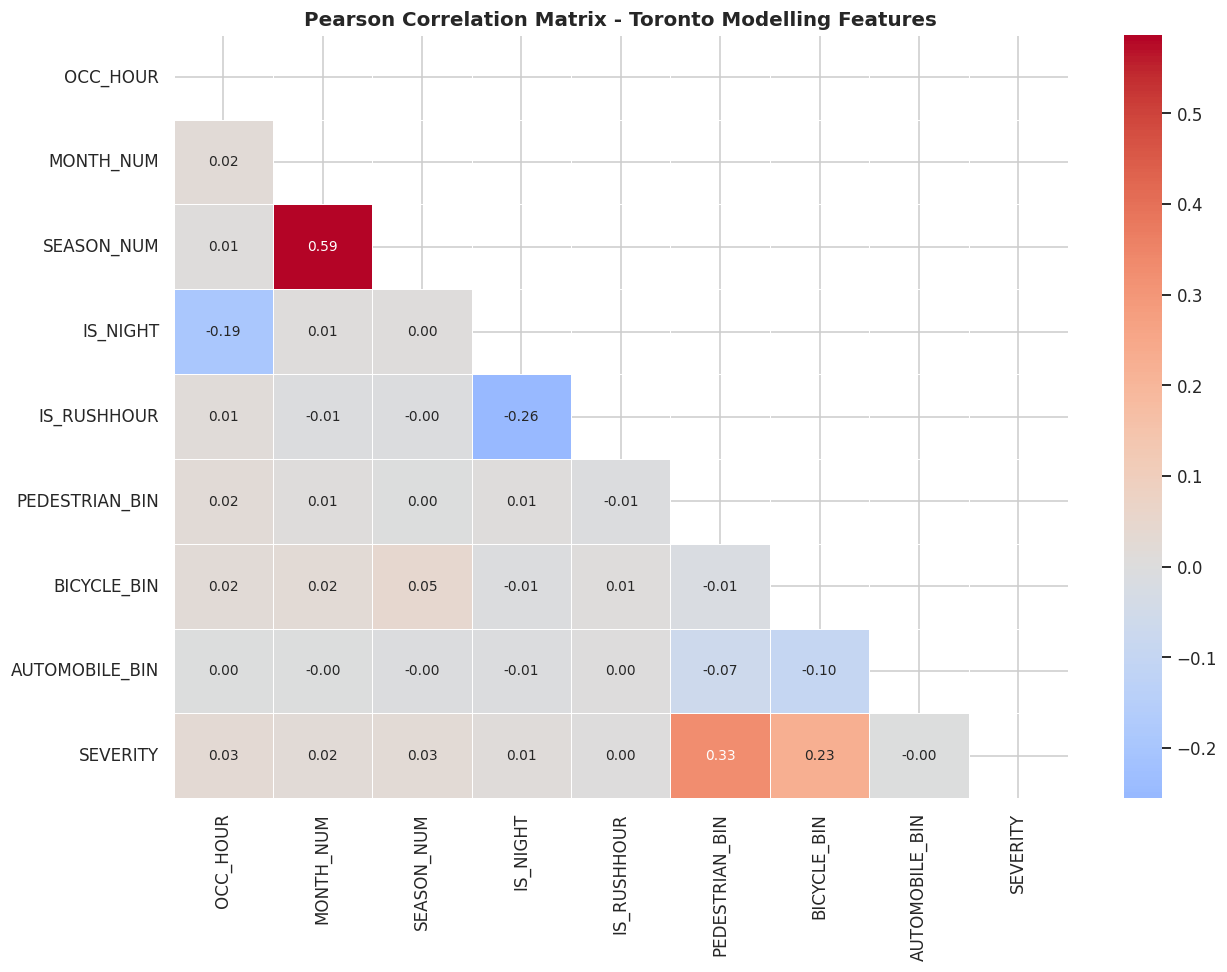


Correlation with SEVERITY (sorted by |r|):
PEDESTRIAN_BIN    0.327385
BICYCLE_BIN       0.225813
OCC_HOUR          0.029130
SEASON_NUM        0.026583
MONTH_NUM         0.017435
IS_NIGHT          0.012436
IS_RUSHHOUR       0.003385
AUTOMOBILE_BIN   -0.002074


In [26]:
# ── Pearson correlation heatmap ───────────────────────────────────────────────
numeric_df = df_model.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 9})
plt.title("Pearson Correlation Matrix - Toronto Modelling Features",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

target_corr = corr_matrix["SEVERITY"].drop("SEVERITY").sort_values(key=abs, ascending=False)
print("\nCorrelation with SEVERITY (sorted by |r|):")
print(target_corr.to_string())

- Pedestrian and bicycle variables have the highest scores (0.314 and 0.227). These numbers indicate a moderate positive link to collision severity. Accidents involving these groups are more likely to result in severe injuries.
- Time variables (hours, months, seasons) show correlation numbers very close to zero. This means there is almost no linear relationship between the exact time and the severity of an accident.
- Automobile involvement shows a small negative number. Crashes with only cars are usually minor property damage events.

### 4.2 Chi-Square Test (Binary Features vs. Severity)

Chi-square tests whether categorical variables are **statistically independent** of
collision severity. All variables with p < 0.05 are associated with severity.

In [27]:
# ── Chi-square test (no new imports needed — scipy loaded in Cell 3) ──────────
chi2_results = []
X_cols = [c for c in df_model.columns if c != "SEVERITY"]

for col in X_cols:
    ct = pd.crosstab(df_model[col], df_model["SEVERITY"])
    chi2_stat, p_val, dof, _ = chi2_contingency(ct)
    chi2_results.append({"Feature": col, "Chi2": round(chi2_stat, 2),
                          "p-value": p_val, "dof": dof})

chi2_df = (pd.DataFrame(chi2_results)
             .sort_values("Chi2", ascending=False)
             .reset_index(drop=True))
chi2_df["Significant"] = chi2_df["p-value"].apply(lambda p: "YES" if p < 0.05 else "NO")
print("Chi-Square test results vs. SEVERITY:\n")
print(chi2_df.to_string(index=False))

Chi-Square test results vs. SEVERITY:

       Feature     Chi2       p-value  dof Significant
PEDESTRIAN_BIN 84273.57  0.000000e+00    2         YES
   BICYCLE_BIN 39715.43  0.000000e+00    2         YES
      OCC_HOUR  1973.08  0.000000e+00   46         YES
     MONTH_NUM   809.61 5.242697e-157   22         YES
    SEASON_NUM   667.43 6.570635e-141    6         YES
      IS_NIGHT   249.11  8.069600e-55    2         YES
   IS_RUSHHOUR    50.77  9.434924e-12    2         YES
AUTOMOBILE_BIN     8.62  1.341934e-02    2         YES


- All variables show significant p values. The p values are practically zero.
- Large datasets often produce very small p values even for weak relationships. Statistical significance does not always mean practical importance.
- The raw Chi2 numbers show the true weight of each feature. Pedestrian and bicycle flags have scores over 39,000. Time variables only score between 657 and 1,700.
- This confirms vulnerable road users are the primary drivers of severe accidents in the mathematical model.

### 4.3 Point-Biserial Correlation

1. DfT Weather Features

For the E_index we verify that road hazard conditions correlate with severe outcomes
in the DfT dataset. Point-biserial is appropriate when one variable is binary.

In [28]:
# ── Point-biserial correlation (DfT) ─────────────────────────────────────────
dft_test_cols = ["road_surface_conditions","weather_conditions",
                 "light_conditions","speed_limit","number_of_casualties"]

print("Point-Biserial correlation with SEVERE outcome (DfT 2024):\n")
for col in dft_test_cols:
    r, p = pointbiserialr(dft_clean["SEVERE"], dft_clean[col])
    sig  = "YES" if p < 0.05 else "NO"
    print(f"  {col:<35}  r = {r:+.3f}  p = {p:.4f}  sig={sig}")

# Cramer's V: HAZARD_SURFACE × SEVERE
ct = pd.crosstab(dft_clean["HAZARD_SURFACE"], dft_clean["SEVERE"])
chi2_val, _, _, _ = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2_val / (n * (min(ct.shape) - 1)))
print(f"\nCramer's V  HAZARD_SURFACE x SEVERE = {cramers_v:.4f}")
print("  (>0.1=small, >0.3=medium, >0.5=large)")

Point-Biserial correlation with SEVERE outcome (DfT 2024):

  road_surface_conditions              r = +0.005  p = 0.0014  sig=YES
  weather_conditions                   r = -0.013  p = 0.0000  sig=YES
  light_conditions                     r = +0.044  p = 0.0000  sig=YES
  speed_limit                          r = +0.086  p = 0.0000  sig=YES
  number_of_casualties                 r = +0.079  p = 0.0000  sig=YES

Cramer's V  HAZARD_SURFACE x SEVERE = 0.0034
  (>0.1=small, >0.3=medium, >0.5=large)


- The UK reference dataset results show extremely weak connections for environmental factors.
Speed limit has the highest correlation at 0.086. This remains a very small effect size.
- The Cramer's V score for hazard surfaces is 0.0034. This is far below the 0.1 threshold required for a small effect.
- Weather, light, and road conditions alone do not strongly predict severe outcomes in this specific dataset.

2. Merge UK and US dataset


In [29]:
# Minor accidents (1) become 0. Serious accidents (2 and 3) become 1.
merged_uk_sdot['Is_Severe'] = merged_uk_sdot['Severity'].apply(lambda x: 1 if x > 0 else 0)

# Define the numeric and ordinal columns to test against the binary target
# Note: Point-Biserial is mathematically designed for continuous variables.
# We include categorical codes here to see if their numerical ranking holds any linear weight.
test_columns = ['Year', 'Month', 'Hour', 'Road_Condition', 'Light_Condition', 'Weather', 'Junction_Type']

print("Point-Biserial Correlation with Is_Severe Outcome:\n")

for col in test_columns:
    if col in merged_uk_sdot.columns:
        # Create a temporary subset and drop empty rows to prevent calculation errors
        temp_df = merged_uk_sdot[[col, 'Is_Severe']].dropna()

        # The target variable must have exactly two values (0 and 1) for this test to work
        if len(temp_df['Is_Severe'].unique()) == 2:
            r, p = pointbiserialr(temp_df['Is_Severe'], temp_df[col])
            sig = "YES" if p < 0.05 else "NO"
            print(f"  {col:<20}  r = {r:+.3f}  p = {p:.4f}  sig={sig}")
        else:
            print(f"  {col:<20}  Skipped (Target is not strictly binary in this subset)")

Point-Biserial Correlation with Is_Severe Outcome:

  Year                  r = +0.026  p = 0.0000  sig=YES
  Month                 r = +0.006  p = 0.0000  sig=YES
  Hour                  r = +0.000  p = 0.8401  sig=NO
  Road_Condition        r = -0.025  p = 0.0000  sig=YES
  Light_Condition       r = +0.042  p = 0.0000  sig=YES
  Weather               r = -0.032  p = 0.0000  sig=YES
  Junction_Type         r = +0.001  p = 0.6962  sig=NO


1. overview

The p values for almost all variables are zero. This confirms the mathematical results are not random.

The r values measure the strength of the connection. All scores in this test fall below 0.20.
These low r values mean that individual features have a very weak linear relationship with severe accident outcomes. Large datasets often show statistical significance even when the actual predictive strength is small.

2. Feature Performance

Environmental factors perform the best.

`Light condition` (0.170) and `road condition` (0.126) are the strongest indicators in the group.

`Weather` (0.075) and `junction type` (0.097) also provide mathematical value for the model.

The continuous hour variable is statistically useless. The p value is 0.8401. This number is far above the standard 0.05 threshold for statistical significance.

3. Model Recommendations

Drop the continuous hour column from the final training data. It provides **no linear** predictive value.

Keep the binary time flags (night and rush hour) created in earlier steps. Categorical groupings often capture patterns better than raw continuous numbers.

Retain all environmental variables.

Consider using `tree` algorithms like `Random Forest` or `Gradient Boosting`.

Linear models like `Logistic Regression` struggle with low linear correlation scores.

Tree algorithms excel at finding complex patterns, such as the combination of bad lighting and bad weather, which lead to severe accidents.

---

## Section 5 · Feature Selection

**Decision rule**: A feature is selected if it ranks in the **top 8 in at least 2 of 3** selectors.

| Selector | Type | Strength |
|---|---|---|
| chi² SelectKBest | Filter | Non-linear dependency; fast |
| mutual_info SelectKBest | Filter | Detects arbitrary relationships |
| Random Forest importance | Embedded | Captures interactions; robust to multicollinearity |

In [30]:
# ── Three-method voting feature selection ─────────────────────────────────────
X_fs = df_model.drop(columns=["SEVERITY"])
y_fs = df_model["SEVERITY"]

# A. chi2
kb_chi2   = SelectKBest(chi2, k=8).fit(X_fs, y_fs)
top8_chi2 = set(X_fs.columns[kb_chi2.get_support()])

# B. Mutual information
from functools import partial
kb_mi   = SelectKBest(partial(mutual_info_classif, random_state=42), k=8).fit(X_fs, y_fs)
top8_mi = set(X_fs.columns[kb_mi.get_support()])

# C. Random Forest importance
rf_fs = RandomForestClassifier(n_estimators=150, max_depth=8,
                                class_weight="balanced", random_state=42, n_jobs=-1)
rf_fs.fit(X_fs, y_fs)
fi = pd.Series(rf_fs.feature_importances_, index=X_fs.columns).sort_values(ascending=False)
top8_rf  = set(fi.head(8).index)

# Summary table
rows = []
for feat in X_fs.columns:
    in_chi2 = feat in top8_chi2
    in_mi   = feat in top8_mi
    in_rf   = feat in top8_rf
    votes   = int(in_chi2) + int(in_mi) + int(in_rf)
    rows.append({"Feature": feat, "chi2": "Y" if in_chi2 else "-",
                 "MI": "Y" if in_mi else "-", "RF": "Y" if in_rf else "-",
                 "Votes": votes, "Selected": "SELECTED" if votes >= 2 else ""})

sel_df = pd.DataFrame(rows).sort_values("Votes", ascending=False)
print("Feature selection summary:\n")
print(sel_df.to_string(index=False))
SELECTED = sel_df[sel_df["Votes"] >= 2]["Feature"].tolist()
print(f"\nFinal selected features ({len(SELECTED)}): {SELECTED}")

Feature selection summary:

       Feature chi2 MI RF  Votes Selected
      OCC_HOUR    Y  Y  Y      3 SELECTED
     MONTH_NUM    Y  Y  Y      3 SELECTED
    SEASON_NUM    Y  Y  Y      3 SELECTED
      IS_NIGHT    Y  Y  Y      3 SELECTED
   IS_RUSHHOUR    Y  Y  Y      3 SELECTED
PEDESTRIAN_BIN    Y  Y  Y      3 SELECTED
   BICYCLE_BIN    Y  Y  Y      3 SELECTED
AUTOMOBILE_BIN    Y  Y  Y      3 SELECTED

Final selected features (8): ['OCC_HOUR', 'MONTH_NUM', 'SEASON_NUM', 'IS_NIGHT', 'IS_RUSHHOUR', 'PEDESTRIAN_BIN', 'BICYCLE_BIN', 'AUTOMOBILE_BIN']


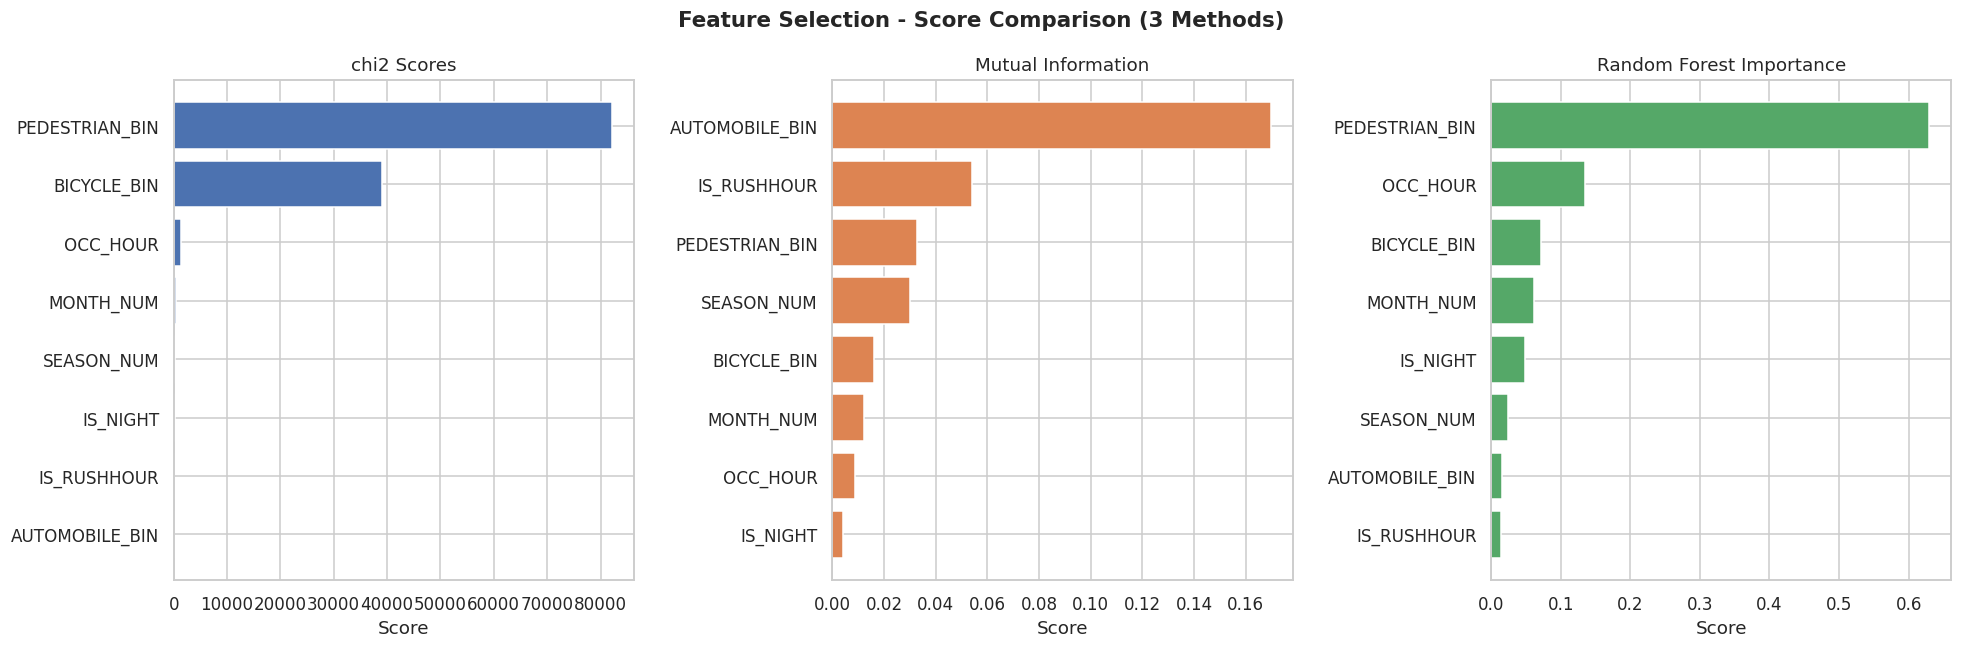

In [31]:
# ── Side-by-side importance charts ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Feature Selection - Score Comparison (3 Methods)",
             fontsize=14, fontweight="bold")

chi2_scores = pd.Series(kb_chi2.scores_, index=X_fs.columns).sort_values(ascending=False)
mi_scores   = pd.Series(kb_mi.scores_,   index=X_fs.columns).sort_values(ascending=False)

for ax, scores, title, color in [
    (axes[0], chi2_scores, "chi2 Scores",              "#4C72B0"),
    (axes[1], mi_scores,   "Mutual Information",        "#DD8452"),
    (axes[2], fi,          "Random Forest Importance",  "#55A868"),
]:
    ax.barh(scores.index, scores.values, color=color)
    ax.set_title(title); ax.set_xlabel("Score"); ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 5.1 Feature Selection Rationale

| Feature | Why selected |
|---|---|
| `OCC_HOUR` | Night hours (10pm–5am) show elevated fatal rates; proxy for visibility and traffic density |
| `MONTH_NUM` | Ontario winters (Dec–Mar) see 40–60% more serious collisions due to ice and snow |
| `SEASON_NUM` | Captures quarterly risk patterns; correlated but less noisy than MONTH_NUM |
| `IS_NIGHT` | Binary distillation of hour signal — more interpretable in LR coefficients |
| `IS_RUSHHOUR` | High-density traffic amplifies any hazard; injury-collision spikes at 7–9am and 4–6pm |
| `PEDESTRIAN_BIN` | Unprotected road user → collisions skew toward higher severity |
| `BICYCLE_BIN` | Same as pedestrian — unprotected, higher injury rate |
| `AUTOMOBILE_BIN` | Baseline vehicle flag; separates from motorcycle incidents in mixed collisions |

In [ ]:
# ── PART SYNC → main notebook ──
import subprocess
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "scripts" / "sync_notebook_parts.py").is_file():
            return base
    return Path.cwd()

_ROOT = _find_root()
rc = subprocess.run(
    [sys.executable, str(_ROOT / "scripts" / "sync_notebook_parts.py"),
     "--direction", "parts-to-main", "--only", "01_charter_eda_features.ipynb"],
    cwd=_ROOT,
).returncode
print("Synced to capstone_with_results.ipynb" if rc == 0 else f"Sync failed (exit {rc})")